In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# ============================================================
# STEP 3 — DEPLOYMENT ENVIRONMENT SETUP
# ============================================================

import torch
import torch.nn as nn
import torch.nn.functional as F

from torchvision.models import (
    resnet50,
    ResNet50_Weights
)

from torchvision import transforms

from pathlib import Path
from PIL import Image

import json
import numpy as np
import matplotlib.pyplot as plt



DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)



STAGE2_BEST_PATH = Path(
    "/content/drive/MyDrive/final_year_project/Apple/checkpoints/"
    "resnet50_attention_stage2_best.pth"
)


print("=" * 65)
print("DEPLOYMENT ENVIRONMENT")
print("=" * 65)

print(f"PyTorch version : {torch.__version__}")
print(f"Device          : {DEVICE}")
print(f"Checkpoint      : {STAGE2_BEST_PATH}")
print(f"Exists          : {STAGE2_BEST_PATH.exists()}")

assert STAGE2_BEST_PATH.exists(), (
    f"Checkpoint not found:\n{STAGE2_BEST_PATH}"
)

print("\nPASS: Deployment environment ready.")

DEPLOYMENT ENVIRONMENT
PyTorch version : 2.11.0+cu128
Device          : cuda
Checkpoint      : /content/drive/MyDrive/final_year_project/Apple/checkpoints/resnet50_attention_stage2_best.pth
Exists          : True

PASS: Deployment environment ready.


In [3]:
# ============================================================
# STEP 4 — RECONSTRUCT FINAL MODEL + LOAD BEST CHECKPOINT
# ============================================================

class ResNet50SelfAttention(nn.Module):

    def __init__(
        self,
        num_classes=8,
        embed_dim=512,
        num_heads=8,
        num_transformer_layers=2,
        mlp_dim=2048,
        dropout=0.2
    ):
        super().__init__()

        # ----------------------------------------------------
        # ResNet50 backbone
        # ----------------------------------------------------

        resnet = resnet50(
            weights=ResNet50_Weights.DEFAULT
        )

        # Remove AvgPool + FC
        self.backbone = nn.Sequential(
            *list(resnet.children())[:-2]
        )

        # ----------------------------------------------------
        # 2048 → 512 projection
        # ----------------------------------------------------

        self.projection = nn.Conv2d(
            2048,
            embed_dim,
            kernel_size=1
        )

        # 7 × 7 = 49 spatial tokens
        self.num_tokens = 7 * 7

        # ----------------------------------------------------
        # Positional embedding
        # ----------------------------------------------------

        self.pos_embedding = nn.Parameter(
            torch.zeros(
                1,
                self.num_tokens,
                embed_dim
            )
        )

        nn.init.trunc_normal_(
            self.pos_embedding,
            std=0.02
        )

        # ----------------------------------------------------
        # Transformer encoder
        # ----------------------------------------------------

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=num_heads,
            dim_feedforward=mlp_dim,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
            norm_first=True
        )

        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_transformer_layers
        )

        # ----------------------------------------------------
        # Classification head
        # ----------------------------------------------------

        self.norm = nn.LayerNorm(
            embed_dim
        )

        self.dropout = nn.Dropout(
            dropout
        )

        self.classifier = nn.Linear(
            embed_dim,
            num_classes
        )


    def forward(self, x):

        # ResNet feature map
        x = self.backbone(x)

        # [B, 2048, 7, 7]
        #       ↓
        # [B, 512, 7, 7]

        x = self.projection(x)

        # Convert spatial locations to tokens
        x = x.flatten(2)

        # [B, 512, 49]
        #       ↓
        # [B, 49, 512]

        x = x.transpose(1, 2)

        # Positional information
        x = x + self.pos_embedding

        # Self-attention
        x = self.transformer(x)

        # Mean token pooling
        x = x.mean(dim=1)

        x = self.norm(x)

        x = self.dropout(x)

        return self.classifier(x)


# ============================================================
# CREATE MODEL
# ============================================================

model = ResNet50SelfAttention(
    num_classes=8
).to(DEVICE)


# ============================================================
# LOAD FINAL CHECKPOINT
# ============================================================

checkpoint = torch.load(
    STAGE2_BEST_PATH,
    map_location=DEVICE,
    weights_only=False
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

model.eval()


# ============================================================
# RESTORE CLASS NAMES FROM CHECKPOINT
# ============================================================

CLASS_NAMES = checkpoint["class_names"]

NUM_CLASSES = len(CLASS_NAMES)


# ============================================================
# VERIFY
# ============================================================

total_params = sum(
    p.numel()
    for p in model.parameters()
)

print("=" * 70)
print("FINAL APPLE MODEL LOADED")
print("=" * 70)

print(f"Architecture     : ResNet50 + Self-Attention")
print(f"Checkpoint Stage : {checkpoint.get('stage', 'Stage 2')}")
print(f"Best Epoch       : {checkpoint['epoch']}")
print(f"Classes          : {NUM_CLASSES}")
print(f"Parameters       : {total_params:,}")
print(f"Device           : {DEVICE}")

print("\nClass Mapping:")

for index, class_name in enumerate(CLASS_NAMES):
    print(
        f"{index} -> {class_name}"
    )


# ============================================================
# SAFETY CHECKS
# ============================================================

assert total_params == 30_892_104
assert NUM_CLASSES == 8

assert CLASS_NAMES[0] == "Apple Alternaria Leaf Spot"
assert CLASS_NAMES[7] == "Healthy Apple Leaf"


print("\nPASS: Stage-2 best Apple model restored successfully.")

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 134MB/s]
/tmp/ipykernel_1264/1220334313.py:75: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(


FINAL APPLE MODEL LOADED
Architecture     : ResNet50 + Self-Attention
Checkpoint Stage : 2
Best Epoch       : 9
Classes          : 8
Parameters       : 30,892,104
Device           : cuda

Class Mapping:
0 -> Apple Alternaria Leaf Spot
1 -> Apple Brown Spot
2 -> Apple Frogeye Leaf Spot
3 -> Apple Mosaic
4 -> Apple Powdery Mildew
5 -> Apple Rust
6 -> Apple Scab
7 -> Healthy Apple Leaf

PASS: Stage-2 best Apple model restored successfully.


SINGLE IMAGE PREDICTION TEST

Upload ONE apple leaf image:


Saving pest-and-disease_apple-scab_banner_1440x500.png to pest-and-disease_apple-scab_banner_1440x500.png


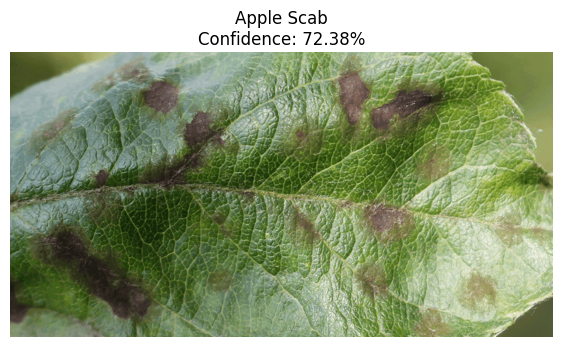

File       : pest-and-disease_apple-scab_banner_1440x500.png
Prediction : Apple Scab
Confidence : 72.38%


In [4]:
# ============================================================
# STEP 5 — GENERIC SINGLE-IMAGE INFERENCE
# ============================================================

from google.colab import files
import io


# ============================================================
# PREPROCESSING
# Same preprocessing used during evaluation
# ============================================================

eval_transform = transforms.Compose([

    transforms.Resize(256),

    transforms.CenterCrop(224),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


# ============================================================
# GENERIC PREDICTION FUNCTION
# ============================================================

def predict_image(
    image,
    model,
    class_names,
    transform,
    device
):

    model.eval()

    image_tensor = transform(
        image
    ).unsqueeze(0).to(device)


    with torch.no_grad():

        outputs = model(
            image_tensor
        )

        probabilities = F.softmax(
            outputs,
            dim=1
        )[0]


    predicted_index = (
        probabilities.argmax().item()
    )

    predicted_class = (
        class_names[predicted_index]
    )

    confidence = (
        probabilities[predicted_index].item()
    )


    return {
        "predicted_index": predicted_index,
        "predicted_class": predicted_class,
        "confidence": confidence,
        "probabilities": probabilities.cpu()
    }


# ============================================================
# UPLOAD IMAGE
# ============================================================

print("=" * 70)
print("SINGLE IMAGE PREDICTION TEST")
print("=" * 70)

print("\nUpload ONE apple leaf image:")

uploaded = files.upload()


# ============================================================
# RUN PREDICTION
# ============================================================

for filename, file_data in uploaded.items():

    image = Image.open(
        io.BytesIO(file_data)
    ).convert("RGB")


    result = predict_image(
        image=image,
        model=model,
        class_names=CLASS_NAMES,
        transform=eval_transform,
        device=DEVICE
    )


    # --------------------------------------------------------
    # DISPLAY IMAGE
    # --------------------------------------------------------

    plt.figure(
        figsize=(7, 6)
    )

    plt.imshow(image)

    plt.axis("off")

    plt.title(
        f"{result['predicted_class']}\n"
        f"Confidence: "
        f"{result['confidence'] * 100:.2f}%"
    )

    plt.show()


    # --------------------------------------------------------
    # RESULT
    # --------------------------------------------------------

    print("=" * 70)

    print(
        f"File       : {filename}"
    )

    print(
        f"Prediction : "
        f"{result['predicted_class']}"
    )

    print(
        f"Confidence : "
        f"{result['confidence'] * 100:.2f}%"
    )

    print("=" * 70)


TOP-3 PLANT DISEASE PREDICTION

Upload ONE leaf image:


Saving pest-and-disease_apple-scab_banner_1440x500.png to pest-and-disease_apple-scab_banner_1440x500 (1).png


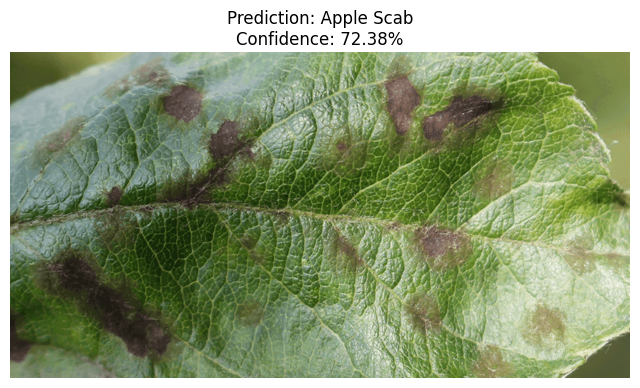


File       : pest-and-disease_apple-scab_banner_1440x500 (1).png
Prediction : Apple Scab
Confidence : 72.38%

TOP-3 PREDICTIONS

1. Apple Scab                      72.38%
2. Healthy Apple Leaf              17.92%
3. Apple Rust                       9.15%


In [5]:
# ============================================================
# STEP 6 — GENERIC TOP-3 PREDICTION
# ============================================================

def predict_image(
    image,
    model,
    class_names,
    transform,
    device,
    top_k=3
):

    model.eval()

    image_tensor = (
        transform(image)
        .unsqueeze(0)
        .to(device)
    )

    with torch.no_grad():

        outputs = model(image_tensor)

        probabilities = F.softmax(
            outputs,
            dim=1
        )[0]


    # --------------------------------------------------------
    # TOP-K PREDICTIONS
    # --------------------------------------------------------

    top_probabilities, top_indices = torch.topk(
        probabilities,
        k=min(top_k, len(class_names))
    )


    top_predictions = []

    for probability, index in zip(
        top_probabilities,
        top_indices
    ):

        top_predictions.append({

            "class_index": index.item(),

            "class_name":
                class_names[index.item()],

            "confidence":
                probability.item()
        })


    return {
        "prediction":
            top_predictions[0]["class_name"],

        "confidence":
            top_predictions[0]["confidence"],

        "top_predictions":
            top_predictions,

        "probabilities":
            probabilities.cpu()
    }


# ============================================================
# UPLOAD IMAGE
# ============================================================

print("=" * 70)
print("TOP-3 PLANT DISEASE PREDICTION")
print("=" * 70)

print("\nUpload ONE leaf image:")

uploaded = files.upload()


# ============================================================
# PREDICT
# ============================================================

for filename, file_data in uploaded.items():

    image = Image.open(
        io.BytesIO(file_data)
    ).convert("RGB")


    result = predict_image(
        image=image,
        model=model,
        class_names=CLASS_NAMES,
        transform=eval_transform,
        device=DEVICE,
        top_k=3
    )


    # --------------------------------------------------------
    # IMAGE
    # --------------------------------------------------------

    plt.figure(figsize=(8, 6))

    plt.imshow(image)

    plt.axis("off")

    plt.title(
        f"Prediction: {result['prediction']}\n"
        f"Confidence: {result['confidence'] * 100:.2f}%"
    )

    plt.show()


    # --------------------------------------------------------
    # RESULTS
    # --------------------------------------------------------

    print("\n" + "=" * 70)

    print(f"File       : {filename}")

    print(
        f"Prediction : "
        f"{result['prediction']}"
    )

    print(
        f"Confidence : "
        f"{result['confidence'] * 100:.2f}%"
    )

    print("=" * 70)

    print("\nTOP-3 PREDICTIONS\n")


    for rank, prediction in enumerate(
        result["top_predictions"],
        start=1
    ):

        print(
            f"{rank}. "
            f"{prediction['class_name']:<30} "
            f"{prediction['confidence'] * 100:6.2f}%"
        )

In [6]:
# ============================================================
# STEP 7 — GENERIC RELIABILITY-AWARE PREDICTION
# ============================================================

import math


def predict_with_reliability(
    image,
    model,
    class_names,
    transform,
    device,
    top_k=3
):

    model.eval()

    # --------------------------------------------------------
    # PREPROCESS
    # --------------------------------------------------------

    image_tensor = (
        transform(image)
        .unsqueeze(0)
        .to(device)
    )


    # --------------------------------------------------------
    # MODEL PREDICTION
    # --------------------------------------------------------

    with torch.no_grad():

        logits = model(image_tensor)

        probabilities = F.softmax(
            logits,
            dim=1
        )[0]


    # --------------------------------------------------------
    # TOP-K
    # --------------------------------------------------------

    top_probabilities, top_indices = torch.topk(
        probabilities,
        k=min(top_k, len(class_names))
    )


    top_predictions = []

    for probability, index in zip(
        top_probabilities,
        top_indices
    ):

        top_predictions.append({
            "class_index": index.item(),
            "class_name": class_names[index.item()],
            "confidence": probability.item()
        })


    # --------------------------------------------------------
    # TOP-1 CONFIDENCE
    # --------------------------------------------------------

    top1_confidence = (
        top_probabilities[0].item()
    )


    # --------------------------------------------------------
    # TOP-2 CONFIDENCE
    # --------------------------------------------------------

    top2_confidence = (
        top_probabilities[1].item()
    )


    # --------------------------------------------------------
    # PREDICTION MARGIN
    #
    # Large margin:
    # model strongly prefers Top-1
    #
    # Small margin:
    # model is confused between classes
    # --------------------------------------------------------

    prediction_margin = (
        top1_confidence -
        top2_confidence
    )


    # --------------------------------------------------------
    # PREDICTIVE ENTROPY
    #
    # Higher entropy = probabilities spread across classes
    # Lower entropy  = concentrated prediction
    # --------------------------------------------------------

    eps = 1e-12

    entropy = -torch.sum(
        probabilities *
        torch.log(probabilities + eps)
    ).item()


    # --------------------------------------------------------
    # NORMALIZED ENTROPY
    #
    # Converts entropy approximately into 0 → 1 range.
    # --------------------------------------------------------

    max_entropy = math.log(
        len(class_names)
    )

    normalized_entropy = (
        entropy / max_entropy
    )


    # --------------------------------------------------------
    # RETURN RAW MEASUREMENTS
    #
    # IMPORTANT:
    # We are NOT deciding Accept/Reject yet.
    # --------------------------------------------------------

    return {

        "prediction":
            top_predictions[0]["class_name"],

        "confidence":
            top1_confidence,

        "top2_confidence":
            top2_confidence,

        "prediction_margin":
            prediction_margin,

        "entropy":
            entropy,

        "normalized_entropy":
            normalized_entropy,

        "top_predictions":
            top_predictions,

        "probabilities":
            probabilities.cpu(),

        "logits":
            logits[0].cpu()
    }


print("PASS: Generic reliability prediction function created.")

PASS: Generic reliability prediction function created.


MODEL RELIABILITY TEST

Upload known Apple images and/or OOD images (Potato, Maize, Mango, non-leaf, etc.):


Saving Septoria1129.png to Septoria1129.png


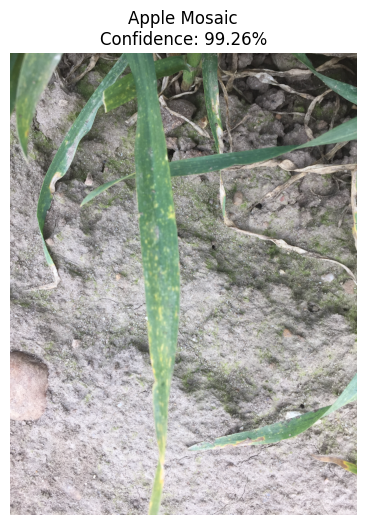


FILE: Septoria1129.png
Prediction          : Apple Mosaic
Top-1 Confidence    : 99.26%
Top-2 Confidence    : 0.52%
Top-1 / Top-2 Margin: 98.75%
Entropy             : 0.0496
Normalized Entropy  : 0.0238

TOP-3 PREDICTIONS
---------------------------------------------------------------------------
1. Apple Mosaic                    99.26%
2. Healthy Apple Leaf               0.52%
3. Apple Scab                       0.16%


In [10]:
# ============================================================
# STEP 8 — TEST RELIABILITY ON KNOWN + OOD IMAGES
# ============================================================

from google.colab import files
import io


print("=" * 75)
print("MODEL RELIABILITY TEST")
print("=" * 75)

print(
    "\nUpload known Apple images and/or OOD images "
    "(Potato, Maize, Mango, non-leaf, etc.):"
)

uploaded = files.upload()


# ============================================================
# PROCESS IMAGES
# ============================================================

for filename, file_data in uploaded.items():

    image = Image.open(
        io.BytesIO(file_data)
    ).convert("RGB")


    result = predict_with_reliability(
        image=image,
        model=model,
        class_names=CLASS_NAMES,
        transform=eval_transform,
        device=DEVICE,
        top_k=3
    )


    # --------------------------------------------------------
    # DISPLAY
    # --------------------------------------------------------

    plt.figure(figsize=(7, 6))

    plt.imshow(image)
    plt.axis("off")

    plt.title(
        f"{result['prediction']}\n"
        f"Confidence: {result['confidence'] * 100:.2f}%"
    )

    plt.show()


    # --------------------------------------------------------
    # RELIABILITY REPORT
    # --------------------------------------------------------

    print("\n" + "=" * 75)
    print(f"FILE: {filename}")
    print("=" * 75)

    print(
        f"Prediction          : {result['prediction']}"
    )

    print(
        f"Top-1 Confidence    : "
        f"{result['confidence'] * 100:.2f}%"
    )

    print(
        f"Top-2 Confidence    : "
        f"{result['top2_confidence'] * 100:.2f}%"
    )

    print(
        f"Top-1 / Top-2 Margin: "
        f"{result['prediction_margin'] * 100:.2f}%"
    )

    print(
        f"Entropy             : "
        f"{result['entropy']:.4f}"
    )

    print(
        f"Normalized Entropy  : "
        f"{result['normalized_entropy']:.4f}"
    )


    print("\nTOP-3 PREDICTIONS")
    print("-" * 75)

    for rank, pred in enumerate(
        result["top_predictions"],
        start=1
    ):

        print(
            f"{rank}. "
            f"{pred['class_name']:<30} "
            f"{pred['confidence'] * 100:6.2f}%"
        )


    print("=" * 75)

In [11]:
# ============================================================
# STEP 9 — RESTORE CLEANED APPLE DATASET FOR OOD REFERENCE
# ============================================================

from pathlib import Path
import zipfile


# ============================================================
# PATHS
# ============================================================

DATASET_ZIP = Path(
    "/content/drive/MyDrive/final_year_project/Apple/"
    "Apple_final_dataset_cleaned.zip"
)

EXTRACT_ROOT = Path(
    "/content/apple_dataset"
)

DATASET_ROOT = (
    EXTRACT_ROOT /
    "Apple_final_dataset"
)


# ============================================================
# VERIFY ZIP
# ============================================================

print("=" * 70)
print("APPLE OOD REFERENCE DATASET")
print("=" * 70)

print(f"ZIP exists     : {DATASET_ZIP.exists()}")
print(f"Dataset loaded : {DATASET_ROOT.exists()}")


assert DATASET_ZIP.exists(), (
    f"Dataset ZIP not found:\n{DATASET_ZIP}"
)


# ============================================================
# EXTRACT ONLY IF NOT ALREADY PRESENT
# ============================================================

if not DATASET_ROOT.exists():

    print("\nExtracting cleaned dataset...")

    EXTRACT_ROOT.mkdir(
        parents=True,
        exist_ok=True
    )

    with zipfile.ZipFile(
        DATASET_ZIP,
        "r"
    ) as zip_ref:

        zip_ref.extractall(
            EXTRACT_ROOT
        )

    print("Extraction complete.")

else:

    print(
        "\nDataset already extracted — "
        "skipping extraction."
    )


# ============================================================
# VERIFY SPLITS
# ============================================================

TRAIN_DIR = DATASET_ROOT / "train"
VAL_DIR = DATASET_ROOT / "validation"
TEST_DIR = DATASET_ROOT / "internal_test"


print("\nDataset root:")
print(DATASET_ROOT)

print("\nSplits:")

print(
    f"Train         : {TRAIN_DIR.exists()}"
)

print(
    f"Validation    : {VAL_DIR.exists()}"
)

print(
    f"Internal Test : {TEST_DIR.exists()}"
)


assert TRAIN_DIR.exists()
assert VAL_DIR.exists()
assert TEST_DIR.exists()


# ============================================================
# COUNT IMAGES
# ============================================================

IMAGE_EXTENSIONS = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".webp"
}


def count_images(folder):

    return sum(
        1
        for path in folder.rglob("*")
        if path.is_file()
        and path.suffix.lower()
        in IMAGE_EXTENSIONS
    )


train_count = count_images(TRAIN_DIR)
val_count = count_images(VAL_DIR)
test_count = count_images(TEST_DIR)


print("\nImage counts:")

print(
    f"Train         : {train_count:,}"
)

print(
    f"Validation    : {val_count:,}"
)

print(
    f"Internal Test : {test_count:,}"
)


# ============================================================
# SAFETY CHECK
# ============================================================

assert train_count == 11731
assert val_count == 2511
assert test_count == 2510


print(
    "\nPASS: Clean Apple reference dataset restored correctly."
)

APPLE OOD REFERENCE DATASET
ZIP exists     : True
Dataset loaded : False

Extracting cleaned dataset...
Extraction complete.

Dataset root:
/content/apple_dataset/Apple_final_dataset

Splits:
Train         : True
Validation    : True
Internal Test : True

Image counts:
Train         : 11,731
Validation    : 2,511
Internal Test : 2,510

PASS: Clean Apple reference dataset restored correctly.


In [12]:
# ============================================================
# STEP 10 — GENERIC 512-D EMBEDDING EXTRACTOR
# ============================================================

def extract_embedding(
    image_tensor,
    model
):
    """
    Extract the final 512-D feature representation
    immediately before dropout/classification.

    Input:
        image_tensor -> [B, 3, 224, 224]

    Output:
        embedding    -> [B, 512]
    """

    model.eval()

    with torch.no_grad():

        # ----------------------------------------------------
        # ResNet50 feature extraction
        # ----------------------------------------------------

        x = model.backbone(
            image_tensor
        )

        # [B, 2048, 7, 7]


        # ----------------------------------------------------
        # 2048 → 512 projection
        # ----------------------------------------------------

        x = model.projection(
            x
        )

        # [B, 512, 7, 7]


        # ----------------------------------------------------
        # Convert feature map to 49 tokens
        # ----------------------------------------------------

        x = x.flatten(2)

        x = x.transpose(
            1,
            2
        )

        # [B, 49, 512]


        # ----------------------------------------------------
        # Add learned positional information
        # ----------------------------------------------------

        x = (
            x +
            model.pos_embedding
        )


        # ----------------------------------------------------
        # Self-attention
        # ----------------------------------------------------

        x = model.transformer(
            x
        )


        # ----------------------------------------------------
        # Token pooling
        # ----------------------------------------------------

        x = x.mean(
            dim=1
        )

        # [B, 512]


        # ----------------------------------------------------
        # Final normalization
        # ----------------------------------------------------

        embedding = model.norm(
            x
        )


    return embedding


# ============================================================
# SANITY TEST
# ============================================================

dummy_image = torch.randn(
    1,
    3,
    224,
    224,
    device=DEVICE
)


embedding = extract_embedding(
    dummy_image,
    model
)


print("=" * 70)
print("FEATURE EXTRACTOR TEST")
print("=" * 70)

print(
    "Input shape     :",
    tuple(dummy_image.shape)
)

print(
    "Embedding shape :",
    tuple(embedding.shape)
)

print(
    "Embedding dtype :",
    embedding.dtype
)

print(
    "Contains NaN    :",
    torch.isnan(embedding).any().item()
)

print(
    "Contains Inf    :",
    torch.isinf(embedding).any().item()
)


# ============================================================
# VERIFY
# ============================================================

assert embedding.shape == (
    1,
    512
)

assert not torch.isnan(
    embedding
).any()

assert not torch.isinf(
    embedding
).any()


print(
    "\nPASS: 512-D embedding extractor working correctly."
)

FEATURE EXTRACTOR TEST
Input shape     : (1, 3, 224, 224)
Embedding shape : (1, 512)
Embedding dtype : torch.float32
Contains NaN    : False
Contains Inf    : False

PASS: 512-D embedding extractor working correctly.


In [13]:
# ============================================================
# STEP 11 — EXTRACT TRAINING REFERENCE EMBEDDINGS
# ============================================================

from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
from tqdm.auto import tqdm


# ============================================================
# TRAIN REFERENCE DATASET
# ============================================================

reference_dataset = ImageFolder(
    root=TRAIN_DIR,
    transform=eval_transform
)


reference_loader = DataLoader(
    reference_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True
)


print("=" * 70)
print("APPLE TRAINING REFERENCE")
print("=" * 70)

print(
    f"Images  : {len(reference_dataset):,}"
)

print(
    f"Classes : {len(reference_dataset.classes)}"
)

print("\nClass mapping:")

for index, class_name in enumerate(
    reference_dataset.classes
):
    print(
        f"{index} -> {class_name}"
    )


# ============================================================
# IMPORTANT CLASS-MAPPING CHECK
# ============================================================

assert (
    reference_dataset.classes
    == list(CLASS_NAMES)
), (
    "Dataset class order does not match model class order."
)


# ============================================================
# EXTRACT EMBEDDINGS
# ============================================================

all_embeddings = []
all_labels = []


model.eval()


for images, labels in tqdm(
    reference_loader,
    desc="Extracting 512-D embeddings"
):

    images = images.to(
        DEVICE,
        non_blocking=True
    )

    embeddings = extract_embedding(
        images,
        model
    )


    all_embeddings.append(
        embeddings.cpu()
    )

    all_labels.append(
        labels
    )


# ============================================================
# COMBINE
# ============================================================

train_embeddings = torch.cat(
    all_embeddings,
    dim=0
)

train_labels = torch.cat(
    all_labels,
    dim=0
)


print("\n" + "=" * 70)
print("REFERENCE EMBEDDING MATRIX")
print("=" * 70)

print(
    "Embedding shape :",
    tuple(train_embeddings.shape)
)

print(
    "Label shape     :",
    tuple(train_labels.shape)
)

print(
    "Contains NaN    :",
    torch.isnan(train_embeddings).any().item()
)

print(
    "Contains Inf    :",
    torch.isinf(train_embeddings).any().item()
)


# ============================================================
# VERIFY
# ============================================================

assert train_embeddings.shape == (
    11731,
    512
)

assert train_labels.shape == (
    11731,
)

assert not torch.isnan(
    train_embeddings
).any()

assert not torch.isinf(
    train_embeddings
).any()


# ============================================================
# SAVE REFERENCE FEATURES TO DRIVE
# ============================================================

OOD_DIR = Path(
    "/content/drive/MyDrive/final_year_project/Apple/"
    "ood_reference"
)

OOD_DIR.mkdir(
    parents=True,
    exist_ok=True
)


REFERENCE_PATH = (
    OOD_DIR /
    "apple_train_embeddings.pt"
)


torch.save(
    {
        "embeddings": train_embeddings,
        "labels": train_labels,
        "class_names": list(CLASS_NAMES),
        "embedding_dim": 512,
        "num_images": len(reference_dataset)
    },
    REFERENCE_PATH
)


print(
    f"\nSaved to:\n{REFERENCE_PATH}"
)

print(
    f"File size: "
    f"{REFERENCE_PATH.stat().st_size / (1024**2):.2f} MB"
)


print(
    "\nPASS: Apple training reference embeddings created and saved."
)

APPLE TRAINING REFERENCE
Images  : 11,731
Classes : 8

Class mapping:
0 -> Apple Alternaria Leaf Spot
1 -> Apple Brown Spot
2 -> Apple Frogeye Leaf Spot
3 -> Apple Mosaic
4 -> Apple Powdery Mildew
5 -> Apple Rust
6 -> Apple Scab
7 -> Healthy Apple Leaf


Extracting 512-D embeddings:   0%|          | 0/184 [00:00<?, ?it/s]


REFERENCE EMBEDDING MATRIX
Embedding shape : (11731, 512)
Label shape     : (11731,)
Contains NaN    : False
Contains Inf    : False

Saved to:
/content/drive/MyDrive/final_year_project/Apple/ood_reference/apple_train_embeddings.pt
File size: 23.00 MB

PASS: Apple training reference embeddings created and saved.


In [14]:
# ============================================================
# STEP 12 — EXTRACT UNSEEN VALIDATION EMBEDDINGS
# ============================================================

from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
from tqdm.auto import tqdm


# ============================================================
# VALIDATION DATASET
# ============================================================

validation_dataset = ImageFolder(
    root=VAL_DIR,
    transform=eval_transform
)

validation_loader = DataLoader(
    validation_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True
)


print("=" * 70)
print("UNSEEN APPLE VALIDATION SET")
print("=" * 70)

print(
    f"Images  : {len(validation_dataset):,}"
)

print(
    f"Classes : {len(validation_dataset.classes)}"
)


# ============================================================
# VERIFY CLASS ORDER
# ============================================================

assert (
    validation_dataset.classes
    == list(CLASS_NAMES)
), (
    "Validation class order does not match model class order."
)


# ============================================================
# EXTRACT EMBEDDINGS + MODEL PREDICTIONS
# ============================================================

val_embeddings_list = []
val_labels_list = []
val_predictions_list = []
val_confidences_list = []


model.eval()


for images, labels in tqdm(
    validation_loader,
    desc="Extracting validation embeddings"
):

    images = images.to(
        DEVICE,
        non_blocking=True
    )

    # --------------------------------------------------------
    # 512-D FEATURES
    # --------------------------------------------------------

    embeddings = extract_embedding(
        images,
        model
    )


    # --------------------------------------------------------
    # NORMAL CLASSIFIER OUTPUT
    # --------------------------------------------------------

    with torch.no_grad():

        logits = model(
            images
        )

        probabilities = F.softmax(
            logits,
            dim=1
        )

        confidences, predictions = (
            probabilities.max(dim=1)
        )


    # --------------------------------------------------------
    # STORE
    # --------------------------------------------------------

    val_embeddings_list.append(
        embeddings.cpu()
    )

    val_labels_list.append(
        labels
    )

    val_predictions_list.append(
        predictions.cpu()
    )

    val_confidences_list.append(
        confidences.cpu()
    )


# ============================================================
# COMBINE
# ============================================================

val_embeddings = torch.cat(
    val_embeddings_list,
    dim=0
)

val_labels = torch.cat(
    val_labels_list,
    dim=0
)

val_predictions = torch.cat(
    val_predictions_list,
    dim=0
)

val_confidences = torch.cat(
    val_confidences_list,
    dim=0
)


# ============================================================
# VERIFY
# ============================================================

assert val_embeddings.shape == (
    2511,
    512
)

assert val_labels.shape == (
    2511,
)


# ============================================================
# CLASSIFICATION SANITY CHECK
# ============================================================

val_accuracy = (
    val_predictions == val_labels
).float().mean().item()


print("\n" + "=" * 70)
print("VALIDATION FEATURE MATRIX")
print("=" * 70)

print(
    "Embedding shape :",
    tuple(val_embeddings.shape)
)

print(
    "Labels          :",
    tuple(val_labels.shape)
)

print(
    "NaN             :",
    torch.isnan(val_embeddings).any().item()
)

print(
    "Inf             :",
    torch.isinf(val_embeddings).any().item()
)

print(
    f"Model Accuracy  : "
    f"{val_accuracy * 100:.2f}%"
)

print(
    f"Mean Confidence : "
    f"{val_confidences.mean().item() * 100:.2f}%"
)


# ============================================================
# SAVE
# ============================================================

VAL_EMBEDDING_PATH = (
    OOD_DIR /
    "apple_validation_embeddings.pt"
)


torch.save(
    {
        "embeddings":
            val_embeddings,

        "labels":
            val_labels,

        "predictions":
            val_predictions,

        "confidences":
            val_confidences,

        "class_names":
            list(CLASS_NAMES),

        "embedding_dim":
            512,

        "num_images":
            len(validation_dataset)
    },
    VAL_EMBEDDING_PATH
)


print(
    f"\nSaved to:\n"
    f"{VAL_EMBEDDING_PATH}"
)

print(
    f"File size: "
    f"{VAL_EMBEDDING_PATH.stat().st_size / (1024**2):.2f} MB"
)


print(
    "\nPASS: Unseen Apple validation embeddings saved."
)

UNSEEN APPLE VALIDATION SET
Images  : 2,511
Classes : 8


Extracting validation embeddings:   0%|          | 0/40 [00:00<?, ?it/s]


VALIDATION FEATURE MATRIX
Embedding shape : (2511, 512)
Labels          : (2511,)
NaN             : False
Inf             : False
Model Accuracy  : 97.01%
Mean Confidence : 97.76%

Saved to:
/content/drive/MyDrive/final_year_project/Apple/ood_reference/apple_validation_embeddings.pt
File size: 4.95 MB

PASS: Unseen Apple validation embeddings saved.


In [15]:
# ============================================================
# STEP 13 — CLASS PROTOTYPES + KNOWN APPLE SIMILARITY
# ============================================================

import torch.nn.functional as F


# ============================================================
# 1. NORMALIZE TRAINING EMBEDDINGS
# ============================================================

train_embeddings_norm = F.normalize(
    train_embeddings.float(),
    p=2,
    dim=1
)


# ============================================================
# 2. BUILD ONE PROTOTYPE PER CLASS
# ============================================================

class_prototypes = []

print("=" * 75)
print("BUILDING APPLE CLASS PROTOTYPES")
print("=" * 75)


for class_index, class_name in enumerate(CLASS_NAMES):

    class_mask = (
        train_labels == class_index
    )

    class_features = (
        train_embeddings_norm[class_mask]
    )

    # Mean direction of this class
    prototype = class_features.mean(
        dim=0
    )

    # Normalize prototype
    prototype = F.normalize(
        prototype,
        p=2,
        dim=0
    )

    class_prototypes.append(
        prototype
    )

    print(
        f"{class_index} "
        f"{class_name:<30} "
        f"{class_features.shape[0]:5d} images"
    )


class_prototypes = torch.stack(
    class_prototypes
)


# ============================================================
# 3. NORMALIZE VALIDATION EMBEDDINGS
# ============================================================

val_embeddings_norm = F.normalize(
    val_embeddings.float(),
    p=2,
    dim=1
)


# ============================================================
# 4. COSINE SIMILARITY AGAINST ALL CLASS PROTOTYPES
# ============================================================

similarity_matrix = (
    val_embeddings_norm
    @ class_prototypes.T
)

# Shape:
# [2511 validation images, 8 classes]


# ============================================================
# 5. NEAREST PROTOTYPE
# ============================================================

max_similarity, nearest_class = (
    similarity_matrix.max(dim=1)
)


# ============================================================
# 6. SIMILARITY TO TRUE CLASS
# ============================================================

true_class_similarity = (
    similarity_matrix[
        torch.arange(len(val_labels)),
        val_labels
    ]
)


# ============================================================
# 7. SUMMARY
# ============================================================

print("\n" + "=" * 75)
print("UNSEEN APPLE — FEATURE SIMILARITY")
print("=" * 75)

print(
    f"Mean nearest similarity : "
    f"{max_similarity.mean().item():.4f}"
)

print(
    f"Median nearest similarity: "
    f"{max_similarity.median().item():.4f}"
)

print(
    f"Minimum similarity      : "
    f"{max_similarity.min().item():.4f}"
)

print(
    f"Maximum similarity      : "
    f"{max_similarity.max().item():.4f}"
)


# ============================================================
# 8. PERCENTILES
# ============================================================

percentiles = [
    0.01,
    0.05,
    0.10,
    0.25,
    0.50,
    0.75,
    0.90,
    0.95,
    0.99
]


print("\nNearest-prototype similarity percentiles:\n")


for q in percentiles:

    value = torch.quantile(
        max_similarity,
        q
    ).item()

    print(
        f"{int(q * 100):>2d}th percentile : "
        f"{value:.4f}"
    )


# ============================================================
# 9. PROTOTYPE CLASS AGREEMENT
# ============================================================

prototype_accuracy = (
    nearest_class == val_labels
).float().mean().item()


print(
    f"\nNearest-prototype class agreement: "
    f"{prototype_accuracy * 100:.2f}%"
)


# ============================================================
# 10. SAVE PROTOTYPES
# ============================================================

PROTOTYPE_PATH = (
    OOD_DIR /
    "apple_class_prototypes.pt"
)


torch.save(
    {
        "class_prototypes":
            class_prototypes,

        "class_names":
            list(CLASS_NAMES),

        "embedding_dim":
            512,

        "method":
            "l2_normalized_class_mean_cosine"
    },
    PROTOTYPE_PATH
)


print(
    f"\nSaved prototypes to:\n"
    f"{PROTOTYPE_PATH}"
)


# ============================================================
# VERIFY
# ============================================================

assert class_prototypes.shape == (
    8,
    512
)

assert similarity_matrix.shape == (
    2511,
    8
)


print(
    "\nPASS: Known Apple feature-space distribution measured."
)


BUILDING APPLE CLASS PROTOTYPES
0 Apple Alternaria Leaf Spot      1106 images
1 Apple Brown Spot                 261 images
2 Apple Frogeye Leaf Spot         2226 images
3 Apple Mosaic                     939 images
4 Apple Powdery Mildew             829 images
5 Apple Rust                      1518 images
6 Apple Scab                      3748 images
7 Healthy Apple Leaf              1104 images

UNSEEN APPLE — FEATURE SIMILARITY
Mean nearest similarity : 0.9132
Median nearest similarity: 0.9392
Minimum similarity      : 0.5034
Maximum similarity      : 0.9965

Nearest-prototype similarity percentiles:

 1th percentile : 0.6504
 5th percentile : 0.7533
10th percentile : 0.8108
25th percentile : 0.8869
50th percentile : 0.9392
75th percentile : 0.9633
90th percentile : 0.9775
95th percentile : 0.9834
99th percentile : 0.9907

Nearest-prototype class agreement: 96.54%

Saved prototypes to:
/content/drive/MyDrive/final_year_project/Apple/ood_reference/apple_class_prototypes.pt

PASS: Kno

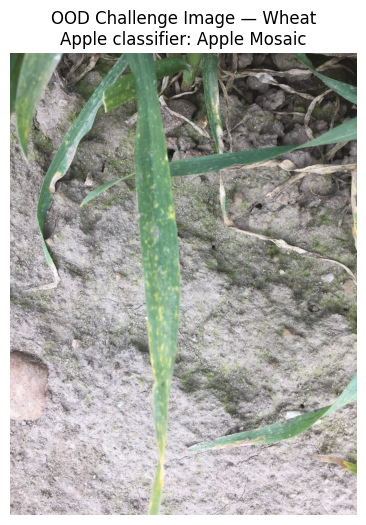

HIGH-CONFIDENCE OOD CHALLENGE
Actual domain             : WHEAT (OOD)
Classifier prediction     : Apple Mosaic
Softmax confidence        : 99.26%
Nearest Apple prototype   : Apple Mosaic
Max prototype similarity  : 0.7655

Comparison with legitimate unseen Apple images:
Apple median              : 0.9392
Apple 5th percentile      : 0.7533
Apple 1st percentile      : 0.6504
Apple minimum             : 0.5034

Similarity to every Apple class:
Apple Mosaic                   0.7655
Healthy Apple Leaf             0.3496
Apple Scab                     0.2815
Apple Rust                     0.1453
Apple Powdery Mildew           -0.0251
Apple Frogeye Leaf Spot        -0.1273
Apple Alternaria Leaf Spot     -0.2577
Apple Brown Spot               -0.2660


In [16]:
# ============================================================
# STEP 14 — TEST HIGH-CONFIDENCE WHEAT OOD IMAGE
# ============================================================

from pathlib import Path


WHEAT_PATH = Path(
    "/content/Septoria1129.png"
)


assert WHEAT_PATH.exists(), (
    "Wheat image not found. "
    "Re-upload Septoria1129.png if the runtime changed."
)


# ============================================================
# LOAD IMAGE
# ============================================================

wheat_image = Image.open(
    WHEAT_PATH
).convert("RGB")


# ============================================================
# PREPROCESS
# ============================================================

wheat_tensor = (
    eval_transform(wheat_image)
    .unsqueeze(0)
    .to(DEVICE)
)


# ============================================================
# NORMAL CLASSIFIER PREDICTION
# ============================================================

model.eval()

with torch.no_grad():

    wheat_logits = model(
        wheat_tensor
    )

    wheat_probabilities = F.softmax(
        wheat_logits,
        dim=1
    )[0]


wheat_confidence, wheat_prediction = (
    wheat_probabilities.max(dim=0)
)


# ============================================================
# EXTRACT 512-D EMBEDDING
# ============================================================

wheat_embedding = extract_embedding(
    wheat_tensor,
    model
).cpu()


wheat_embedding_norm = F.normalize(
    wheat_embedding.float(),
    p=2,
    dim=1
)


# ============================================================
# COMPARE AGAINST 8 APPLE PROTOTYPES
# ============================================================

wheat_similarities = (
    wheat_embedding_norm
    @ class_prototypes.T
)[0]


wheat_max_similarity, wheat_nearest_class = (
    wheat_similarities.max(dim=0)
)


# ============================================================
# RANK ALL APPLE PROTOTYPES
# ============================================================

sorted_similarity, sorted_indices = torch.sort(
    wheat_similarities,
    descending=True
)


# ============================================================
# DISPLAY IMAGE
# ============================================================

plt.figure(figsize=(7, 6))

plt.imshow(wheat_image)

plt.axis("off")

plt.title(
    "OOD Challenge Image — Wheat\n"
    f"Apple classifier: "
    f"{CLASS_NAMES[wheat_prediction.item()]}"
)

plt.show()


# ============================================================
# REPORT
# ============================================================

print("=" * 75)
print("HIGH-CONFIDENCE OOD CHALLENGE")
print("=" * 75)

print(
    "Actual domain             : WHEAT (OOD)"
)

print(
    f"Classifier prediction     : "
    f"{CLASS_NAMES[wheat_prediction.item()]}"
)

print(
    f"Softmax confidence        : "
    f"{wheat_confidence.item() * 100:.2f}%"
)

print(
    f"Nearest Apple prototype   : "
    f"{CLASS_NAMES[wheat_nearest_class.item()]}"
)

print(
    f"Max prototype similarity  : "
    f"{wheat_max_similarity.item():.4f}"
)


print("\nComparison with legitimate unseen Apple images:")

print(
    f"Apple median              : "
    f"{max_similarity.median().item():.4f}"
)

print(
    f"Apple 5th percentile      : "
    f"{torch.quantile(max_similarity, 0.05).item():.4f}"
)

print(
    f"Apple 1st percentile      : "
    f"{torch.quantile(max_similarity, 0.01).item():.4f}"
)

print(
    f"Apple minimum             : "
    f"{max_similarity.min().item():.4f}"
)


print("\nSimilarity to every Apple class:")

for similarity, index in zip(
    sorted_similarity,
    sorted_indices
):

    print(
        f"{CLASS_NAMES[index.item()]:30s} "
        f"{similarity.item():.4f}"
    )


print("=" * 75)

In [17]:
# ============================================================
# STEP 15 — kNN FEATURE-SPACE OOD BASELINE
# ============================================================

# We already have:
# train_embeddings_norm -> [11731, 512]
# val_embeddings_norm   -> [2511, 512]

K = 10
CHUNK_SIZE = 256


# ============================================================
# FUNCTION — MEAN SIMILARITY TO K NEAREST TRAINING FEATURES
# ============================================================

def knn_similarity_scores(
    query_embeddings,
    reference_embeddings,
    k=10,
    chunk_size=256
):

    scores = []

    for start in range(
        0,
        len(query_embeddings),
        chunk_size
    ):

        end = min(
            start + chunk_size,
            len(query_embeddings)
        )

        query_chunk = query_embeddings[
            start:end
        ]

        # Cosine similarity because both sides are normalized
        similarities = (
            query_chunk
            @ reference_embeddings.T
        )

        top_k_similarities = torch.topk(
            similarities,
            k=k,
            dim=1
        ).values

        # Mean similarity to K nearest known samples
        chunk_scores = (
            top_k_similarities.mean(dim=1)
        )

        scores.append(
            chunk_scores.cpu()
        )

    return torch.cat(scores)


# ============================================================
# KNOWN APPLE VALIDATION SCORES
# ============================================================

print("=" * 75)
print("kNN FEATURE-SPACE OOD ANALYSIS")
print("=" * 75)

print(
    f"Reference images : {len(train_embeddings_norm):,}"
)

print(
    f"Validation images: {len(val_embeddings_norm):,}"
)

print(
    f"K nearest        : {K}"
)


val_knn_scores = knn_similarity_scores(
    query_embeddings=val_embeddings_norm,
    reference_embeddings=train_embeddings_norm,
    k=K,
    chunk_size=CHUNK_SIZE
)


# ============================================================
# SUMMARY
# ============================================================

print("\nKNOWN UNSEEN APPLE — kNN SCORES")
print("-" * 75)

print(
    f"Mean    : {val_knn_scores.mean().item():.4f}"
)

print(
    f"Median  : {val_knn_scores.median().item():.4f}"
)

print(
    f"Minimum : {val_knn_scores.min().item():.4f}"
)

print(
    f"Maximum : {val_knn_scores.max().item():.4f}"
)


print("\nPercentiles:\n")

for q in [
    0.01,
    0.05,
    0.10,
    0.25,
    0.50,
    0.75,
    0.90,
    0.95,
    0.99
]:

    print(
        f"{int(q*100):>2d}th percentile : "
        f"{torch.quantile(val_knn_scores, q).item():.4f}"
    )


# ============================================================
# WHEAT kNN SCORE
# ============================================================

wheat_knn_score = knn_similarity_scores(
    query_embeddings=wheat_embedding_norm,
    reference_embeddings=train_embeddings_norm,
    k=K,
    chunk_size=1
)[0]


print("\n" + "=" * 75)
print("99.26% CONFIDENT WHEAT CHALLENGE")
print("=" * 75)

print(
    f"Softmax confidence : "
    f"{wheat_confidence.item()*100:.2f}%"
)

print(
    f"Prototype score    : "
    f"{wheat_max_similarity.item():.4f}"
)

print(
    f"kNN score (K={K})     : "
    f"{wheat_knn_score.item():.4f}"
)


# ============================================================
# POSITION RELATIVE TO APPLE DISTRIBUTION
# ============================================================

percent_below_wheat = (
    val_knn_scores <= wheat_knn_score
).float().mean().item()


print(
    f"\nApple validation images with\n"
    f"kNN score <= Wheat : "
    f"{percent_below_wheat * 100:.2f}%"
)


print(
    "\nPASS: kNN OOD baseline measured."
)


kNN FEATURE-SPACE OOD ANALYSIS
Reference images : 11,731
Validation images: 2,511
K nearest        : 10

KNOWN UNSEEN APPLE — kNN SCORES
---------------------------------------------------------------------------
Mean    : 0.9729
Median  : 0.9790
Minimum : 0.7598
Maximum : 0.9947

Percentiles:

 1th percentile : 0.8791
 5th percentile : 0.9357
10th percentile : 0.9509
25th percentile : 0.9677
50th percentile : 0.9790
75th percentile : 0.9860
90th percentile : 0.9898
95th percentile : 0.9914
99th percentile : 0.9931

99.26% CONFIDENT WHEAT CHALLENGE
Softmax confidence : 99.26%
Prototype score    : 0.7655
kNN score (K=10)     : 0.8711

Apple validation images with
kNN score <= Wheat : 0.72%

PASS: kNN OOD baseline measured.


In [18]:
# ============================================================
# STEP 16 — SAVE kNN OOD BASELINE
# ============================================================

KNN_BASELINE_PATH = (
    OOD_DIR /
    "apple_knn_ood_baseline.pt"
)

torch.save(
    {
        # Configuration
        "k": K,
        "embedding_dim": 512,
        "similarity": "cosine",
        "aggregation": "mean_top_k",

        # Known Apple validation distribution
        "validation_knn_scores": val_knn_scores,

        # Current challenge example
        "wheat_knn_score": wheat_knn_score.cpu(),

        # Useful statistics
        "validation_mean":
            val_knn_scores.mean().item(),

        "validation_median":
            val_knn_scores.median().item(),

        "validation_min":
            val_knn_scores.min().item(),

        "validation_p01":
            torch.quantile(
                val_knn_scores, 0.01
            ).item(),

        "validation_p05":
            torch.quantile(
                val_knn_scores, 0.05
            ).item(),

        "validation_p10":
            torch.quantile(
                val_knn_scores, 0.10
            ).item(),

        "class_names":
            list(CLASS_NAMES)
    },
    KNN_BASELINE_PATH
)


print("=" * 70)
print("kNN OOD BASELINE SAVED")
print("=" * 70)

print(f"K                  : {K}")
print(
    f"Apple mean         : "
    f"{val_knn_scores.mean().item():.4f}"
)

print(
    f"Apple 5th pct      : "
    f"{torch.quantile(val_knn_scores, 0.05).item():.4f}"
)

print(
    f"Apple 1st pct      : "
    f"{torch.quantile(val_knn_scores, 0.01).item():.4f}"
)

print(
    f"Wheat score        : "
    f"{wheat_knn_score.item():.4f}"
)

print(
    f"Apple <= Wheat     : "
    f"{percent_below_wheat * 100:.2f}%"
)

print(
    f"\nSaved to:\n{KNN_BASELINE_PATH}"
)

print(
    f"\nFile size: "
    f"{KNN_BASELINE_PATH.stat().st_size / 1024:.2f} KB"
)

print(
    "\nPASS: kNN OOD baseline safely stored."
)

kNN OOD BASELINE SAVED
K                  : 10
Apple mean         : 0.9729
Apple 5th pct      : 0.9357
Apple 1st pct      : 0.8791
Wheat score        : 0.8711
Apple <= Wheat     : 0.72%

Saved to:
/content/drive/MyDrive/final_year_project/Apple/ood_reference/apple_knn_ood_baseline.pt

File size: 12.28 KB

PASS: kNN OOD baseline safely stored.


In [19]:
# ============================================================
# STEP 17 — CREATE STRUCTURED OOD EVALUATION WORKSPACE
# ============================================================

from pathlib import Path


OOD_DATA_ROOT = Path(
    "/content/drive/MyDrive/final_year_project/Apple/"
    "ood_dataset"
)

OOD_CALIBRATION_DIR = (
    OOD_DATA_ROOT / "calibration"
)

OOD_TEST_DIR = (
    OOD_DATA_ROOT / "test"
)


CROP_FOLDERS = [
    "Wheat",
    "Potato",
    "Maize",
    "Mango",
    "Other"
]


# ============================================================
# CREATE DIRECTORIES
# ============================================================

for crop in CROP_FOLDERS:

    (
        OOD_CALIBRATION_DIR / crop
    ).mkdir(
        parents=True,
        exist_ok=True
    )

    (
        OOD_TEST_DIR / crop
    ).mkdir(
        parents=True,
        exist_ok=True
    )


# ============================================================
# VERIFY
# ============================================================

print("=" * 70)
print("OOD DATASET WORKSPACE")
print("=" * 70)

print(
    f"Root:\n{OOD_DATA_ROOT}\n"
)


print("CALIBRATION")

for crop in CROP_FOLDERS:

    path = (
        OOD_CALIBRATION_DIR / crop
    )

    print(
        f"  {crop:<10} -> {path.exists()}"
    )


print("\nTEST")

for crop in CROP_FOLDERS:

    path = (
        OOD_TEST_DIR / crop
    )

    print(
        f"  {crop:<10} -> {path.exists()}"
    )


print(
    "\nPASS: OOD calibration/test workspace created."
)

OOD DATASET WORKSPACE
Root:
/content/drive/MyDrive/final_year_project/Apple/ood_dataset

CALIBRATION
  Wheat      -> True
  Potato     -> True
  Maize      -> True
  Mango      -> True
  Other      -> True

TEST
  Wheat      -> True
  Potato     -> True
  Maize      -> True
  Mango      -> True
  Other      -> True

PASS: OOD calibration/test workspace created.


In [20]:
# ============================================================
# STEP 18 — CHECK OOD DATASET STATUS
# ============================================================

import shutil
from pathlib import Path


# ============================================================
# ADD EXISTING WHEAT CHALLENGE IMAGE TO CALIBRATION
# ============================================================

WHEAT_SOURCE = Path(
    "/content/Septoria1129.png"
)

WHEAT_DESTINATION = (
    OOD_CALIBRATION_DIR /
    "Wheat" /
    "Septoria1129.png"
)


if WHEAT_SOURCE.exists():

    if not WHEAT_DESTINATION.exists():

        shutil.copy2(
            WHEAT_SOURCE,
            WHEAT_DESTINATION
        )

        print(
            "Wheat challenge image copied "
            "to calibration set."
        )

    else:

        print(
            "Wheat challenge image already "
            "exists in calibration set."
        )

else:

    print(
        "Wheat challenge image is no longer "
        "available in /content."
    )


# ============================================================
# SUPPORTED IMAGE EXTENSIONS
# ============================================================

IMAGE_EXTENSIONS = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".webp",
    ".tif",
    ".tiff"
}


def count_images(folder):

    return sum(
        1
        for file in folder.rglob("*")
        if (
            file.is_file()
            and file.suffix.lower()
            in IMAGE_EXTENSIONS
        )
    )


# ============================================================
# REPORT
# ============================================================

print("\n" + "=" * 70)
print("OOD DATASET STATUS")
print("=" * 70)


calibration_total = 0
test_total = 0


for crop in CROP_FOLDERS:

    calibration_count = count_images(
        OOD_CALIBRATION_DIR / crop
    )

    test_count = count_images(
        OOD_TEST_DIR / crop
    )

    calibration_total += calibration_count
    test_total += test_count

    print(
        f"{crop:<10} "
        f"Calibration: {calibration_count:4d}   "
        f"Test: {test_count:4d}"
    )


print("-" * 70)

print(
    f"{'TOTAL':<10} "
    f"Calibration: {calibration_total:4d}   "
    f"Test: {test_total:4d}"
)


print("\nPASS: OOD dataset status checked.")

Wheat challenge image copied to calibration set.

OOD DATASET STATUS
Wheat      Calibration:    1   Test:    0
Potato     Calibration:    0   Test:    0
Maize      Calibration:    0   Test:    0
Mango      Calibration:    0   Test:    0
Other      Calibration:    0   Test:    0
----------------------------------------------------------------------
TOTAL      Calibration:    1   Test:    0

PASS: OOD dataset status checked.


In [21]:
# ============================================================
# STEP 19 — DOWNLOAD REAL-WORLD OOD DATASET (PLANTDOC)
# ============================================================

from pathlib import Path
import subprocess


PLANTDOC_ROOT = Path(
    "/content/PlantDoc-Dataset"
)


# ============================================================
# DOWNLOAD
# ============================================================

if not PLANTDOC_ROOT.exists():

    print("Downloading PlantDoc dataset...")

    subprocess.run(
        [
            "git",
            "clone",
            "--depth",
            "1",
            "https://github.com/pratikkayal/PlantDoc-Dataset.git",
            str(PLANTDOC_ROOT)
        ],
        check=True
    )

else:

    print("PlantDoc already downloaded.")


# ============================================================
# CHECK STRUCTURE
# ============================================================

print("\n" + "=" * 70)
print("PLANTDOC DATASET")
print("=" * 70)

print(
    f"Location : {PLANTDOC_ROOT}"
)

print(
    f"Exists   : {PLANTDOC_ROOT.exists()}"
)


print("\nTop-level contents:")

for item in sorted(
    PLANTDOC_ROOT.iterdir()
):

    print(
        f"  {item.name}"
    )


# ============================================================
# COUNT IMAGES
# ============================================================

IMAGE_EXTENSIONS = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".webp"
}


all_plantdoc_images = [
    file
    for file in PLANTDOC_ROOT.rglob("*")
    if (
        file.is_file()
        and file.suffix.lower()
        in IMAGE_EXTENSIONS
    )
]


print(
    f"\nTotal image files found: "
    f"{len(all_plantdoc_images):,}"
)


print(
    "\nPASS: PlantDoc downloaded and ready for OOD preparation."
)


PLANTDOC DATASET
Location : /content/PlantDoc-Dataset
Exists   : True

Top-level contents:
  .git
  LICENSE.txt
  PlantDoc_Examples.png
  README.md
  test
  train

Total image files found: 2,579

PASS: PlantDoc downloaded and ready for OOD preparation.


In [22]:
# ============================================================
# STEP 20 — INSPECT PLANTDOC CLASS STRUCTURE
# ============================================================

from pathlib import Path


PLANTDOC_TRAIN = PLANTDOC_ROOT / "train"
PLANTDOC_TEST  = PLANTDOC_ROOT / "test"


IMAGE_EXTENSIONS = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".webp"
}


def count_class_images(folder):

    return sum(
        1
        for file in folder.rglob("*")
        if (
            file.is_file()
            and file.suffix.lower()
            in IMAGE_EXTENSIONS
        )
    )


# ============================================================
# TRAIN CLASSES
# ============================================================

train_classes = sorted([
    folder
    for folder in PLANTDOC_TRAIN.iterdir()
    if folder.is_dir()
])


# ============================================================
# TEST CLASSES
# ============================================================

test_classes = sorted([
    folder
    for folder in PLANTDOC_TEST.iterdir()
    if folder.is_dir()
])


print("=" * 80)
print("PLANTDOC TRAIN CLASSES")
print("=" * 80)

train_total = 0

for index, folder in enumerate(train_classes):

    count = count_class_images(folder)

    train_total += count

    print(
        f"{index:2d} | "
        f"{folder.name:<45} "
        f"{count:4d}"
    )


print("-" * 80)
print(f"TRAIN TOTAL: {train_total:,}")


print("\n" + "=" * 80)
print("PLANTDOC TEST CLASSES")
print("=" * 80)

test_total = 0

for index, folder in enumerate(test_classes):

    count = count_class_images(folder)

    test_total += count

    print(
        f"{index:2d} | "
        f"{folder.name:<45} "
        f"{count:4d}"
    )


print("-" * 80)
print(f"TEST TOTAL: {test_total:,}")


# ============================================================
# CLASS SET COMPARISON
# ============================================================

train_names = {
    folder.name
    for folder in train_classes
}

test_names = {
    folder.name
    for folder in test_classes
}


print("\n" + "=" * 80)
print("CLASS CONSISTENCY")
print("=" * 80)

print(
    "Train classes :",
    len(train_names)
)

print(
    "Test classes  :",
    len(test_names)
)

print(
    "\nOnly in train:",
    sorted(train_names - test_names)
)

print(
    "Only in test :",
    sorted(test_names - train_names)
)


print(
    "\nPASS: PlantDoc class structure inspected."
)

PLANTDOC TRAIN CLASSES
 0 | Apple Scab Leaf                                 83
 1 | Apple leaf                                      82
 2 | Apple rust leaf                                 79
 3 | Bell_pepper leaf                                53
 4 | Bell_pepper leaf spot                           62
 5 | Blueberry leaf                                 106
 6 | Cherry leaf                                     47
 7 | Corn Gray leaf spot                             64
 8 | Corn leaf blight                               180
 9 | Corn rust leaf                                 106
10 | Peach leaf                                     103
11 | Potato leaf early blight                       109
12 | Potato leaf late blight                         97
13 | Raspberry leaf                                 112
14 | Soyabean leaf                                   57
15 | Squash Powdery mildew leaf                     124
16 | Strawberry leaf                                 88
17 | Tomato Early blight 

In [23]:
# ============================================================
# STEP 21 — BUILD NON-APPLE PLANTDOC OOD DATASET
# ============================================================

import shutil
from pathlib import Path


PLANTDOC_OOD_ROOT = (
    OOD_DATA_ROOT /
    "PlantDoc_non_apple"
)

PLANTDOC_OOD_CALIBRATION = (
    PLANTDOC_OOD_ROOT /
    "calibration"
)

PLANTDOC_OOD_TEST = (
    PLANTDOC_OOD_ROOT /
    "test"
)


# ============================================================
# APPLE CLASSES — MUST NOT BE USED AS OOD
# ============================================================

APPLE_PLANTDOC_CLASSES = {
    "Apple Scab Leaf",
    "Apple leaf",
    "Apple rust leaf"
}


# ============================================================
# RESET GENERATED PLANTDOC OOD FOLDERS
# ============================================================

if PLANTDOC_OOD_ROOT.exists():

    shutil.rmtree(
        PLANTDOC_OOD_ROOT
    )


PLANTDOC_OOD_CALIBRATION.mkdir(
    parents=True,
    exist_ok=True
)

PLANTDOC_OOD_TEST.mkdir(
    parents=True,
    exist_ok=True
)


# ============================================================
# COPY FUNCTION
# ============================================================

def copy_non_apple_split(
    source_root,
    destination_root
):

    copied_total = 0
    copied_classes = {}

    for class_folder in sorted(
        source_root.iterdir()
    ):

        if not class_folder.is_dir():
            continue

        class_name = class_folder.name

        # --------------------------------------------
        # EXCLUDE ALL APPLE CLASSES
        # --------------------------------------------

        if class_name in APPLE_PLANTDOC_CLASSES:
            continue


        image_files = [
            file
            for file in class_folder.rglob("*")
            if (
                file.is_file()
                and file.suffix.lower()
                in IMAGE_EXTENSIONS
            )
        ]


        if len(image_files) == 0:
            continue


        destination_class = (
            destination_root /
            class_name
        )

        destination_class.mkdir(
            parents=True,
            exist_ok=True
        )


        for index, source_file in enumerate(
            image_files
        ):

            # Unique filename prevents accidental
            # collision if nested directories exist.

            destination_file = (
                destination_class /
                f"{index:05d}_{source_file.name}"
            )

            shutil.copy2(
                source_file,
                destination_file
            )


        copied_classes[class_name] = len(
            image_files
        )

        copied_total += len(
            image_files
        )


    return copied_total, copied_classes


# ============================================================
# PLANTDOC TRAIN → OOD CALIBRATION
# ============================================================

calibration_total, calibration_classes = (
    copy_non_apple_split(
        PLANTDOC_TRAIN,
        PLANTDOC_OOD_CALIBRATION
    )
)


# ============================================================
# PLANTDOC TEST → FINAL OOD TEST
# ============================================================

test_total, test_classes = (
    copy_non_apple_split(
        PLANTDOC_TEST,
        PLANTDOC_OOD_TEST
    )
)


# ============================================================
# VERIFY NO APPLE FOLDERS
# ============================================================

calibration_folder_names = {
    folder.name
    for folder in PLANTDOC_OOD_CALIBRATION.iterdir()
    if folder.is_dir()
}

test_folder_names = {
    folder.name
    for folder in PLANTDOC_OOD_TEST.iterdir()
    if folder.is_dir()
}


assert (
    calibration_folder_names
    & APPLE_PLANTDOC_CLASSES
) == set()

assert (
    test_folder_names
    & APPLE_PLANTDOC_CLASSES
) == set()


# ============================================================
# REPORT
# ============================================================

print("=" * 75)
print("PLANTDOC NON-APPLE OOD DATASET")
print("=" * 75)

print("\nExcluded Apple classes:")

for name in sorted(
    APPLE_PLANTDOC_CLASSES
):
    print(
        f"  - {name}"
    )


print("\nCALIBRATION")
print("-" * 75)

for class_name, count in sorted(
    calibration_classes.items()
):

    print(
        f"{class_name:<45} "
        f"{count:4d}"
    )


print("-" * 75)

print(
    f"Calibration classes : "
    f"{len(calibration_classes)}"
)

print(
    f"Calibration images  : "
    f"{calibration_total:,}"
)


print("\nFINAL OOD TEST")
print("-" * 75)

for class_name, count in sorted(
    test_classes.items()
):

    print(
        f"{class_name:<45} "
        f"{count:4d}"
    )


print("-" * 75)

print(
    f"Test classes : "
    f"{len(test_classes)}"
)

print(
    f"Test images  : "
    f"{test_total:,}"
)


print(
    f"\nSaved under:\n"
    f"{PLANTDOC_OOD_ROOT}"
)


print(
    "\nPASS: Non-Apple PlantDoc OOD dataset created."
)

PLANTDOC NON-APPLE OOD DATASET

Excluded Apple classes:
  - Apple Scab Leaf
  - Apple leaf
  - Apple rust leaf

CALIBRATION
---------------------------------------------------------------------------
Bell_pepper leaf                                53
Bell_pepper leaf spot                           62
Blueberry leaf                                 106
Cherry leaf                                     47
Corn Gray leaf spot                             64
Corn leaf blight                               180
Corn rust leaf                                 106
Peach leaf                                     103
Potato leaf early blight                       109
Potato leaf late blight                         97
Raspberry leaf                                 112
Soyabean leaf                                   57
Squash Powdery mildew leaf                     124
Strawberry leaf                                 88
Tomato Early blight leaf                        79
Tomato Septoria leaf spot          

In [24]:
# ============================================================
# STEP 22 — PLANTDOC OOD CALIBRATION EMBEDDINGS + kNN SCORES
# ============================================================

from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
from tqdm.auto import tqdm
import torch.nn.functional as F


# ============================================================
# 1. LOAD OOD CALIBRATION DATASET
# ============================================================

ood_cal_dataset = ImageFolder(
    root=PLANTDOC_OOD_CALIBRATION,
    transform=eval_transform
)

ood_cal_loader = DataLoader(
    ood_cal_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True
)


print("=" * 75)
print("PLANTDOC OOD CALIBRATION")
print("=" * 75)

print(
    f"Images  : {len(ood_cal_dataset):,}"
)

print(
    f"Classes : {len(ood_cal_dataset.classes)}"
)


assert len(ood_cal_dataset) == 2098


# ============================================================
# 2. EXTRACT EMBEDDINGS + SOFTMAX INFORMATION
# ============================================================

ood_embeddings_list = []
ood_labels_list = []
ood_predictions_list = []
ood_confidences_list = []


model.eval()


for images, labels in tqdm(
    ood_cal_loader,
    desc="Extracting OOD calibration embeddings"
):

    images = images.to(
        DEVICE,
        non_blocking=True
    )

    # 512-D embedding
    embeddings = extract_embedding(
        images,
        model
    )


    # Apple classifier output
    with torch.no_grad():

        logits = model(images)

        probabilities = F.softmax(
            logits,
            dim=1
        )

        confidences, predictions = (
            probabilities.max(dim=1)
        )


    ood_embeddings_list.append(
        embeddings.cpu()
    )

    ood_labels_list.append(
        labels
    )

    ood_predictions_list.append(
        predictions.cpu()
    )

    ood_confidences_list.append(
        confidences.cpu()
    )


# ============================================================
# 3. COMBINE
# ============================================================

ood_cal_embeddings = torch.cat(
    ood_embeddings_list,
    dim=0
)

ood_cal_labels = torch.cat(
    ood_labels_list,
    dim=0
)

ood_cal_predictions = torch.cat(
    ood_predictions_list,
    dim=0
)

ood_cal_confidences = torch.cat(
    ood_confidences_list,
    dim=0
)


# ============================================================
# 4. NORMALIZE EMBEDDINGS
# ============================================================

ood_cal_embeddings_norm = F.normalize(
    ood_cal_embeddings.float(),
    p=2,
    dim=1
)


# ============================================================
# 5. kNN SCORES AGAINST APPLE TRAINING REFERENCE
# ============================================================

ood_cal_knn_scores = knn_similarity_scores(
    query_embeddings=ood_cal_embeddings_norm,
    reference_embeddings=train_embeddings_norm,
    k=K,
    chunk_size=256
)


# ============================================================
# 6. BASIC DISTRIBUTION
# ============================================================

print("\n" + "=" * 75)
print("OOD kNN SCORE DISTRIBUTION")
print("=" * 75)

print(
    f"Mean    : "
    f"{ood_cal_knn_scores.mean().item():.4f}"
)

print(
    f"Median  : "
    f"{ood_cal_knn_scores.median().item():.4f}"
)

print(
    f"Minimum : "
    f"{ood_cal_knn_scores.min().item():.4f}"
)

print(
    f"Maximum : "
    f"{ood_cal_knn_scores.max().item():.4f}"
)


print("\nPercentiles:\n")

for q in [
    0.01,
    0.05,
    0.10,
    0.25,
    0.50,
    0.75,
    0.90,
    0.95,
    0.99
]:

    value = torch.quantile(
        ood_cal_knn_scores,
        q
    ).item()

    print(
        f"{int(q*100):>2d}th percentile : "
        f"{value:.4f}"
    )


# ============================================================
# 7. COMPARE AGAINST APPLE VALIDATION
# ============================================================

print("\n" + "=" * 75)
print("APPLE vs OOD")
print("=" * 75)

print(
    f"Apple mean     : "
    f"{val_knn_scores.mean().item():.4f}"
)

print(
    f"OOD mean       : "
    f"{ood_cal_knn_scores.mean().item():.4f}"
)

print()

print(
    f"Apple median   : "
    f"{val_knn_scores.median().item():.4f}"
)

print(
    f"OOD median     : "
    f"{ood_cal_knn_scores.median().item():.4f}"
)


# ============================================================
# 8. HOW MANY OOD IMAGES ARE HIGH-CONFIDENCE?
# ============================================================

high_conf_90 = (
    ood_cal_confidences >= 0.90
).float().mean().item()

high_conf_95 = (
    ood_cal_confidences >= 0.95
).float().mean().item()

high_conf_99 = (
    ood_cal_confidences >= 0.99
).float().mean().item()


print("\n" + "=" * 75)
print("APPLE CLASSIFIER OVERCONFIDENCE ON OOD")
print("=" * 75)

print(
    f"OOD predicted >=90% confidence : "
    f"{high_conf_90 * 100:.2f}%"
)

print(
    f"OOD predicted >=95% confidence : "
    f"{high_conf_95 * 100:.2f}%"
)

print(
    f"OOD predicted >=99% confidence : "
    f"{high_conf_99 * 100:.2f}%"
)


# ============================================================
# 9. SAVE — IMPORTANT
# ============================================================

OOD_CAL_FEATURE_PATH = (
    OOD_DIR /
    "plantdoc_ood_calibration_embeddings.pt"
)


torch.save(
    {
        "embeddings":
            ood_cal_embeddings,

        "labels":
            ood_cal_labels,

        "predictions":
            ood_cal_predictions,

        "confidences":
            ood_cal_confidences,

        "knn_scores":
            ood_cal_knn_scores,

        "class_names":
            ood_cal_dataset.classes,

        "k":
            K,

        "num_images":
            len(ood_cal_dataset)
    },
    OOD_CAL_FEATURE_PATH
)


print(
    f"\nSaved to:\n"
    f"{OOD_CAL_FEATURE_PATH}"
)

print(
    f"\nFile size: "
    f"{OOD_CAL_FEATURE_PATH.stat().st_size / (1024**2):.2f} MB"
)


# ============================================================
# VERIFY
# ============================================================

assert ood_cal_embeddings.shape == (
    2098,
    512
)

assert ood_cal_knn_scores.shape == (
    2098,
)


print(
    "\nPASS: PlantDoc OOD calibration distribution measured."
)

PLANTDOC OOD CALIBRATION
Images  : 2,098
Classes : 25


Extracting OOD calibration embeddings:   0%|          | 0/33 [00:00<?, ?it/s]


OOD kNN SCORE DISTRIBUTION
Mean    : 0.8590
Median  : 0.8703
Minimum : 0.5336
Maximum : 0.9899

Percentiles:

 1th percentile : 0.6614
 5th percentile : 0.7199
10th percentile : 0.7527
25th percentile : 0.8121
50th percentile : 0.8704
75th percentile : 0.9163
90th percentile : 0.9481
95th percentile : 0.9609
99th percentile : 0.9775

APPLE vs OOD
Apple mean     : 0.9729
OOD mean       : 0.8590

Apple median   : 0.9790
OOD median     : 0.8703

APPLE CLASSIFIER OVERCONFIDENCE ON OOD
OOD predicted >=90% confidence : 62.20%
OOD predicted >=95% confidence : 52.24%
OOD predicted >=99% confidence : 34.99%

Saved to:
/content/drive/MyDrive/final_year_project/Apple/ood_reference/plantdoc_ood_calibration_embeddings.pt

File size: 4.15 MB

PASS: PlantDoc OOD calibration distribution measured.


In [25]:
# ============================================================
# STEP 23 — kNN OOD PERFORMANCE + THRESHOLD ANALYSIS
# ============================================================

import numpy as np
from sklearn.metrics import (
    roc_auc_score,
    roc_curve
)


# ============================================================
# 1. PREPARE SCORES
#
# Higher kNN score = more likely APPLE / in-distribution
#
# ID  = 1
# OOD = 0
# ============================================================

id_scores = (
    val_knn_scores
    .cpu()
    .numpy()
)

ood_scores = (
    ood_cal_knn_scores
    .cpu()
    .numpy()
)


y_true = np.concatenate([
    np.ones(len(id_scores)),
    np.zeros(len(ood_scores))
])

all_scores = np.concatenate([
    id_scores,
    ood_scores
])


# ============================================================
# 2. AUROC
# ============================================================

auroc = roc_auc_score(
    y_true,
    all_scores
)


print("=" * 78)
print("kNN OOD DETECTOR — CALIBRATION PERFORMANCE")
print("=" * 78)

print(
    f"Apple ID images : {len(id_scores):,}"
)

print(
    f"OOD images      : {len(ood_scores):,}"
)

print(
    f"\nAUROC           : {auroc:.4f}"
)


# ============================================================
# 3. THRESHOLD FUNCTION
#
# score >= threshold -> ACCEPT AS APPLE
# score < threshold  -> REJECT AS OOD
# ============================================================

def evaluate_threshold(threshold):

    id_acceptance = np.mean(
        id_scores >= threshold
    )

    id_false_reject = (
        1.0 - id_acceptance
    )

    ood_rejection = np.mean(
        ood_scores < threshold
    )

    ood_false_accept = (
        1.0 - ood_rejection
    )

    return {
        "threshold": threshold,
        "id_acceptance": id_acceptance,
        "id_false_reject": id_false_reject,
        "ood_rejection": ood_rejection,
        "ood_false_accept": ood_false_accept
    }


# ============================================================
# 4. ID-PRESERVING THRESHOLDS
#
# These thresholds are derived ONLY from Apple validation.
# ============================================================

threshold_99_id = np.quantile(
    id_scores,
    0.01
)

threshold_95_id = np.quantile(
    id_scores,
    0.05
)

threshold_90_id = np.quantile(
    id_scores,
    0.10
)


thresholds_to_test = [
    ("99% ID target", threshold_99_id),
    ("95% ID target", threshold_95_id),
    ("90% ID target", threshold_90_id),
]


print("\n" + "=" * 78)
print("ID-PRESERVING THRESHOLDS")
print("=" * 78)

print(
    f"{'Policy':<18}"
    f"{'Threshold':>12}"
    f"{'ID Accept':>12}"
    f"{'ID Reject':>12}"
    f"{'OOD Reject':>13}"
    f"{'OOD Accept':>13}"
)

print("-" * 78)


threshold_results = {}


for name, threshold in thresholds_to_test:

    result = evaluate_threshold(
        threshold
    )

    threshold_results[name] = result

    print(
        f"{name:<18}"
        f"{threshold:>12.4f}"
        f"{result['id_acceptance']*100:>11.2f}%"
        f"{result['id_false_reject']*100:>11.2f}%"
        f"{result['ood_rejection']*100:>12.2f}%"
        f"{result['ood_false_accept']*100:>12.2f}%"
    )


# ============================================================
# 5. FPR95
#
# Standard OOD-style metric:
# false-positive rate for OOD when ~95% of ID is retained.
# ============================================================

result_95 = threshold_results[
    "95% ID target"
]

fpr95 = result_95[
    "ood_false_accept"
]


print("\n" + "=" * 78)
print("SUMMARY")
print("=" * 78)

print(
    f"AUROC                    : "
    f"{auroc:.4f}"
)

print(
    f"95%-ID threshold         : "
    f"{threshold_95_id:.4f}"
)

print(
    f"ID acceptance            : "
    f"{result_95['id_acceptance']*100:.2f}%"
)

print(
    f"OOD rejection            : "
    f"{result_95['ood_rejection']*100:.2f}%"
)

print(
    f"OOD false acceptance     : "
    f"{fpr95*100:.2f}%"
)

print(
    f"FPR95                     : "
    f"{fpr95*100:.2f}%"
)


# ============================================================
# 6. WHEAT CHALLENGE UNDER THESE POLICIES
# ============================================================

wheat_score = wheat_knn_score.item()


print("\n" + "=" * 78)
print("99.26%-CONFIDENT WHEAT CHALLENGE")
print("=" * 78)

print(
    f"Wheat kNN score : {wheat_score:.4f}\n"
)


for name, threshold in thresholds_to_test:

    decision = (
        "ACCEPT"
        if wheat_score >= threshold
        else "REJECT"
    )

    print(
        f"{name:<18} "
        f"threshold={threshold:.4f}  "
        f"-> {decision}"
    )


print(
    "\nPASS: kNN threshold trade-off measured."
)

kNN OOD DETECTOR — CALIBRATION PERFORMANCE
Apple ID images : 2,511
OOD images      : 2,098

AUROC           : 0.9645

ID-PRESERVING THRESHOLDS
Policy               Threshold   ID Accept   ID Reject   OOD Reject   OOD Accept
------------------------------------------------------------------------------
99% ID target           0.8791      98.96%       1.04%       55.10%       44.90%
95% ID target           0.9357      94.98%       5.02%       84.08%       15.92%
90% ID target           0.9509      90.00%      10.00%       90.99%        9.01%

SUMMARY
AUROC                    : 0.9645
95%-ID threshold         : 0.9357
ID acceptance            : 94.98%
OOD rejection            : 84.08%
OOD false acceptance     : 15.92%
FPR95                     : 15.92%

99.26%-CONFIDENT WHEAT CHALLENGE
Wheat kNN score : 0.8711

99% ID target      threshold=0.8791  -> REJECT
95% ID target      threshold=0.9357  -> REJECT
90% ID target      threshold=0.9509  -> REJECT

PASS: kNN threshold trade-off measured

In [26]:
# ============================================================
# STEP 24 — PER-CLASS OOD FAILURE ANALYSIS
# ============================================================

import numpy as np


# Diagnostic operating point only
DIAGNOSTIC_THRESHOLD = float(
    threshold_95_id
)


ood_scores_np = (
    ood_cal_knn_scores
    .cpu()
    .numpy()
)

ood_labels_np = (
    ood_cal_labels
    .cpu()
    .numpy()
)

ood_conf_np = (
    ood_cal_confidences
    .cpu()
    .numpy()
)

ood_predictions_np = (
    ood_cal_predictions
    .cpu()
    .numpy()
)


print("=" * 100)
print("PER-CLASS OOD FAILURE ANALYSIS")
print("=" * 100)

print(
    f"Diagnostic threshold : "
    f"{DIAGNOSTIC_THRESHOLD:.4f}"
)

print(
    "Rule                 : "
    "kNN >= threshold → falsely accepted as Apple"
)


print("\n")

print(
    f"{'OOD CLASS':<42}"
    f"{'N':>6}"
    f"{'MEAN':>9}"
    f"{'MAX':>9}"
    f"{'ACCEPT':>9}"
    f"{'ACCEPT %':>11}"
    f"{'>=99% CONF':>12}"
)

print("-" * 100)


class_results = []


# ============================================================
# ANALYZE EACH PLANTDOC CLASS
# ============================================================

for class_index, class_name in enumerate(
    ood_cal_dataset.classes
):

    mask = (
        ood_labels_np == class_index
    )

    class_scores = (
        ood_scores_np[mask]
    )

    class_conf = (
        ood_conf_np[mask]
    )


    n = len(
        class_scores
    )


    false_accept_count = int(
        np.sum(
            class_scores
            >= DIAGNOSTIC_THRESHOLD
        )
    )


    false_accept_rate = (
        false_accept_count / n
    )


    confidence_99_rate = np.mean(
        class_conf >= 0.99
    )


    result = {
        "class_name":
            class_name,

        "n":
            n,

        "mean_score":
            float(
                np.mean(class_scores)
            ),

        "max_score":
            float(
                np.max(class_scores)
            ),

        "false_accept_count":
            false_accept_count,

        "false_accept_rate":
            false_accept_rate,

        "confidence_99_rate":
            confidence_99_rate
    }


    class_results.append(
        result
    )


# ============================================================
# SORT BY FALSE ACCEPTANCE RATE
# ============================================================

class_results = sorted(
    class_results,
    key=lambda x: (
        x["false_accept_rate"],
        x["mean_score"]
    ),
    reverse=True
)


# ============================================================
# PRINT
# ============================================================

for result in class_results:

    print(
        f"{result['class_name']:<42}"
        f"{result['n']:>6d}"
        f"{result['mean_score']:>9.4f}"
        f"{result['max_score']:>9.4f}"
        f"{result['false_accept_count']:>9d}"
        f"{result['false_accept_rate']*100:>10.2f}%"
        f"{result['confidence_99_rate']*100:>11.2f}%"
    )


# ============================================================
# OVERALL FALSE ACCEPTED OOD IMAGES
# ============================================================

false_accept_mask = (
    ood_scores_np
    >= DIAGNOSTIC_THRESHOLD
)


num_false_accepted = int(
    false_accept_mask.sum()
)


print("\n" + "=" * 100)
print("OVERALL")
print("=" * 100)

print(
    f"OOD images                  : "
    f"{len(ood_scores_np):,}"
)

print(
    f"Correctly rejected          : "
    f"{len(ood_scores_np) - num_false_accepted:,}"
)

print(
    f"Falsely accepted            : "
    f"{num_false_accepted:,}"
)

print(
    f"False acceptance rate       : "
    f"{num_false_accepted / len(ood_scores_np) * 100:.2f}%"
)


# ============================================================
# WHAT APPLE CLASSES DO FALSE OOD IMAGES BECOME?
# ============================================================

false_apple_predictions = (
    ood_predictions_np[
        false_accept_mask
    ]
)


print("\n" + "=" * 100)
print("APPLE CLASSES ASSIGNED TO FALSELY ACCEPTED OOD IMAGES")
print("=" * 100)


for apple_index, apple_class in enumerate(
    CLASS_NAMES
):

    count = int(
        np.sum(
            false_apple_predictions
            == apple_index
        )
    )

    percentage = (
        count / num_false_accepted * 100
        if num_false_accepted > 0
        else 0
    )

    print(
        f"{apple_class:<32} "
        f"{count:4d} "
        f"({percentage:6.2f}%)"
    )


print(
    "\nPASS: Per-class OOD failure analysis complete."
)

PER-CLASS OOD FAILURE ANALYSIS
Diagnostic threshold : 0.9357
Rule                 : kNN >= threshold → falsely accepted as Apple


OOD CLASS                                      N     MEAN      MAX   ACCEPT   ACCEPT %  >=99% CONF
----------------------------------------------------------------------------------------------------
Peach leaf                                   103   0.8788   0.9813       33     32.04%      55.34%
Cherry leaf                                   47   0.8789   0.9817       15     31.91%      46.81%
Corn Gray leaf spot                           64   0.8785   0.9805       19     29.69%      59.38%
Raspberry leaf                               112   0.8752   0.9825       31     27.68%      47.32%
grape leaf                                    57   0.8845   0.9768       14     24.56%      36.84%
Tomato leaf mosaic virus                      44   0.8687   0.9899       10     22.73%      40.91%
Squash Powdery mildew leaf                   124   0.8842   0.9766       28

In [27]:
# ============================================================
# STEP 25 — CLASS-CONDITIONAL kNN OOD SCORE
# ============================================================

K_CLASS = 10
CHUNK_SIZE = 256


# ============================================================
# FUNCTION
#
# For each image:
#   1. Take classifier-predicted Apple class
#   2. Compare only with training embeddings from that class
#   3. Mean cosine similarity of top-K neighbors
# ============================================================

def class_conditional_knn_scores(
    query_embeddings,
    predicted_classes,
    reference_embeddings,
    reference_labels,
    k=10,
    chunk_size=256
):

    final_scores = torch.empty(
        len(query_embeddings),
        dtype=torch.float32
    )

    for class_index in range(
        len(CLASS_NAMES)
    ):

        # Queries predicted as this Apple class
        query_mask = (
            predicted_classes == class_index
        )

        query_indices = torch.where(
            query_mask
        )[0]


        if len(query_indices) == 0:
            continue


        # Training references belonging ONLY
        # to this Apple class
        reference_mask = (
            reference_labels == class_index
        )

        class_reference = (
            reference_embeddings[
                reference_mask
            ]
        )


        # Process queries in chunks
        for start in range(
            0,
            len(query_indices),
            chunk_size
        ):

            end = min(
                start + chunk_size,
                len(query_indices)
            )

            current_indices = (
                query_indices[start:end]
            )

            query_chunk = (
                query_embeddings[
                    current_indices
                ]
            )


            similarities = (
                query_chunk
                @ class_reference.T
            )


            top_k = torch.topk(
                similarities,
                k=min(
                    k,
                    len(class_reference)
                ),
                dim=1
            ).values


            scores = (
                top_k.mean(dim=1)
            )


            final_scores[
                current_indices
            ] = scores.cpu()


    return final_scores


# ============================================================
# APPLE VALIDATION
# ============================================================

val_class_knn_scores = (
    class_conditional_knn_scores(
        query_embeddings=
            val_embeddings_norm,

        predicted_classes=
            val_predictions,

        reference_embeddings=
            train_embeddings_norm,

        reference_labels=
            train_labels,

        k=K_CLASS,

        chunk_size=CHUNK_SIZE
    )
)


# ============================================================
# PLANTDOC OOD CALIBRATION
# ============================================================

ood_class_knn_scores = (
    class_conditional_knn_scores(
        query_embeddings=
            ood_cal_embeddings_norm,

        predicted_classes=
            ood_cal_predictions,

        reference_embeddings=
            train_embeddings_norm,

        reference_labels=
            train_labels,

        k=K_CLASS,

        chunk_size=CHUNK_SIZE
    )
)


# ============================================================
# DISTRIBUTIONS
# ============================================================

print("=" * 78)
print("CLASS-CONDITIONAL kNN")
print("=" * 78)

print("\nAPPLE VALIDATION")

print(
    f"Mean    : "
    f"{val_class_knn_scores.mean():.4f}"
)

print(
    f"Median  : "
    f"{val_class_knn_scores.median():.4f}"
)

print(
    f"5th pct : "
    f"{torch.quantile(val_class_knn_scores, 0.05):.4f}"
)

print(
    f"1st pct : "
    f"{torch.quantile(val_class_knn_scores, 0.01):.4f}"
)


print("\nNON-APPLE OOD")

print(
    f"Mean    : "
    f"{ood_class_knn_scores.mean():.4f}"
)

print(
    f"Median  : "
    f"{ood_class_knn_scores.median():.4f}"
)

print(
    f"95th pct: "
    f"{torch.quantile(ood_class_knn_scores, 0.95):.4f}"
)

print(
    f"99th pct: "
    f"{torch.quantile(ood_class_knn_scores, 0.99):.4f}"
)


# ============================================================
# AUROC
# ============================================================

id_class_scores_np = (
    val_class_knn_scores.numpy()
)

ood_class_scores_np = (
    ood_class_knn_scores.numpy()
)


y_true_class = np.concatenate([
    np.ones(
        len(id_class_scores_np)
    ),
    np.zeros(
        len(ood_class_scores_np)
    )
])


all_class_scores = np.concatenate([
    id_class_scores_np,
    ood_class_scores_np
])


class_knn_auroc = roc_auc_score(
    y_true_class,
    all_class_scores
)


# ============================================================
# 95% ID OPERATING POINT
# ============================================================

class_threshold_95 = np.quantile(
    id_class_scores_np,
    0.05
)


class_id_accept = np.mean(
    id_class_scores_np
    >= class_threshold_95
)


class_ood_reject = np.mean(
    ood_class_scores_np
    < class_threshold_95
)


class_ood_accept = (
    1 - class_ood_reject
)


print("\n" + "=" * 78)
print("PERFORMANCE")
print("=" * 78)

print(
    f"AUROC                : "
    f"{class_knn_auroc:.4f}"
)

print(
    f"95%-ID threshold     : "
    f"{class_threshold_95:.4f}"
)

print(
    f"ID acceptance        : "
    f"{class_id_accept*100:.2f}%"
)

print(
    f"OOD rejection        : "
    f"{class_ood_reject*100:.2f}%"
)

print(
    f"OOD false acceptance : "
    f"{class_ood_accept*100:.2f}%"
)


# ============================================================
# COMPARE WITH ORIGINAL GLOBAL kNN
# ============================================================

print("\n" + "=" * 78)
print("GLOBAL kNN vs CLASS-CONDITIONAL kNN")
print("=" * 78)

print(
    f"{'Method':<28}"
    f"{'AUROC':>10}"
    f"{'OOD Reject @95ID':>20}"
)

print("-" * 58)

print(
    f"{'Global kNN':<28}"
    f"{auroc:>10.4f}"
    f"{84.08:>19.2f}%"
)

print(
    f"{'Class-conditional kNN':<28}"
    f"{class_knn_auroc:>10.4f}"
    f"{class_ood_reject*100:>19.2f}%"
)


# ============================================================
# WHEAT CHALLENGE
# ============================================================

wheat_pred_tensor = torch.tensor([
    wheat_prediction.item()
])

wheat_class_knn = (
    class_conditional_knn_scores(
        query_embeddings=
            wheat_embedding_norm,

        predicted_classes=
            wheat_pred_tensor,

        reference_embeddings=
            train_embeddings_norm,

        reference_labels=
            train_labels,

        k=K_CLASS,

        chunk_size=1
    )[0]
)


print("\n" + "=" * 78)
print("WHEAT CHALLENGE")
print("=" * 78)

print(
    f"Classifier prediction : "
    f"{CLASS_NAMES[wheat_prediction.item()]}"
)

print(
    f"Softmax confidence    : "
    f"{wheat_confidence.item()*100:.2f}%"
)

print(
    f"Global kNN            : "
    f"{wheat_knn_score.item():.4f}"
)

print(
    f"Class-conditional kNN : "
    f"{wheat_class_knn.item():.4f}"
)

print(
    f"95%-ID threshold      : "
    f"{class_threshold_95:.4f}"
)

print(
    "Decision              : "
    + (
        "ACCEPT"
        if wheat_class_knn.item()
        >= class_threshold_95
        else "REJECT"
    )
)


print(
    "\nPASS: Class-conditional kNN experiment complete."
)

CLASS-CONDITIONAL kNN

APPLE VALIDATION
Mean    : 0.9724
Median  : 0.9790
5th pct : 0.9341
1st pct : 0.8729

NON-APPLE OOD
Mean    : 0.8466
Median  : 0.8652
95th pct: 0.9609
99th pct: 0.9775

PERFORMANCE
AUROC                : 0.9633
95%-ID threshold     : 0.9341
ID acceptance        : 94.98%
OOD rejection        : 84.03%
OOD false acceptance : 15.97%

GLOBAL kNN vs CLASS-CONDITIONAL kNN
Method                           AUROC    OOD Reject @95ID
----------------------------------------------------------
Global kNN                      0.9645              84.08%
Class-conditional kNN           0.9633              84.03%

WHEAT CHALLENGE
Classifier prediction : Apple Mosaic
Softmax confidence    : 99.26%
Global kNN            : 0.8711
Class-conditional kNN : 0.8711
95%-ID threshold      : 0.9341
Decision              : REJECT

PASS: Class-conditional kNN experiment complete.


In [28]:
# ============================================================
# STEP 26 — COMPARE kNN WITH SOFTMAX-BASED OOD SIGNALS
# ============================================================

import numpy as np
import torch
import torch.nn.functional as F

from sklearn.metrics import roc_auc_score


# ============================================================
# HELPER — CALCULATE SOFTMAX RELIABILITY SIGNALS
# ============================================================

def get_softmax_signals_from_embeddings_dataset(
    predictions,
    confidences
):
    return (
        predictions.cpu().numpy(),
        confidences.cpu().numpy()
    )


# ============================================================
# WE NEED FULL PROBABILITY DISTRIBUTIONS
#
# Re-run validation and OOD through classifier.
# No embeddings are recomputed.
# ============================================================

def collect_probability_signals(loader):

    all_max_conf = []
    all_margin = []
    all_entropy = []

    model.eval()

    with torch.no_grad():

        for images, _ in loader:

            images = images.to(
                DEVICE,
                non_blocking=True
            )

            logits = model(images)

            probs = F.softmax(
                logits,
                dim=1
            )

            # Top-2
            top2 = torch.topk(
                probs,
                k=2,
                dim=1
            ).values

            max_conf = top2[:, 0]

            margin = (
                top2[:, 0]
                - top2[:, 1]
            )

            entropy = -torch.sum(
                probs
                * torch.log(
                    probs + 1e-12
                ),
                dim=1
            )

            # Convert entropy so HIGHER = more ID-like
            neg_entropy = -entropy

            all_max_conf.append(
                max_conf.cpu()
            )

            all_margin.append(
                margin.cpu()
            )

            all_entropy.append(
                neg_entropy.cpu()
            )


    return (
        torch.cat(all_max_conf).numpy(),
        torch.cat(all_margin).numpy(),
        torch.cat(all_entropy).numpy()
    )


# ============================================================
# APPLE VALIDATION SIGNALS
# ============================================================

print(
    "Collecting Apple validation probability signals..."
)

(
    val_softmax,
    val_margin,
    val_neg_entropy
) = collect_probability_signals(
    validation_loader
)


# ============================================================
# OOD CALIBRATION SIGNALS
# ============================================================

print(
    "Collecting PlantDoc OOD probability signals..."
)

(
    ood_softmax,
    ood_margin,
    ood_neg_entropy
) = collect_probability_signals(
    ood_cal_loader
)


# ============================================================
# kNN SCORES
# ============================================================

val_knn_np = (
    val_knn_scores.numpy()
)

ood_knn_np = (
    ood_cal_knn_scores.numpy()
)


# ============================================================
# LABELS
#
# 1 = Apple / ID
# 0 = OOD
# ============================================================

labels = np.concatenate([
    np.ones(len(val_knn_np)),
    np.zeros(len(ood_knn_np))
])


# ============================================================
# HELPER — AUROC
# ============================================================

def combined_auroc(
    id_score,
    ood_score
):

    scores = np.concatenate([
        id_score,
        ood_score
    ])

    return roc_auc_score(
        labels,
        scores
    )


# ============================================================
# INDIVIDUAL SIGNALS
# ============================================================

results = []


results.append((
    "Global kNN",
    combined_auroc(
        val_knn_np,
        ood_knn_np
    )
))


results.append((
    "Softmax confidence",
    combined_auroc(
        val_softmax,
        ood_softmax
    )
))


results.append((
    "Top1-Top2 margin",
    combined_auroc(
        val_margin,
        ood_margin
    )
))


results.append((
    "Negative entropy",
    combined_auroc(
        val_neg_entropy,
        ood_neg_entropy
    )
))


# ============================================================
# STANDARDIZE USING APPLE VALIDATION DISTRIBUTION
#
# Allows scores with different scales to be combined.
# ============================================================

def standardize_using_id(
    id_values,
    ood_values
):

    mean = np.mean(
        id_values
    )

    std = np.std(
        id_values
    ) + 1e-12

    return (
        (id_values - mean) / std,
        (ood_values - mean) / std
    )


knn_id_z, knn_ood_z = (
    standardize_using_id(
        val_knn_np,
        ood_knn_np
    )
)

conf_id_z, conf_ood_z = (
    standardize_using_id(
        val_softmax,
        ood_softmax
    )
)

margin_id_z, margin_ood_z = (
    standardize_using_id(
        val_margin,
        ood_margin
    )
)

entropy_id_z, entropy_ood_z = (
    standardize_using_id(
        val_neg_entropy,
        ood_neg_entropy
    )
)


# ============================================================
# SIMPLE COMBINATIONS
# ============================================================

combinations = {

    "kNN + Confidence":
        (
            knn_id_z + conf_id_z,
            knn_ood_z + conf_ood_z
        ),

    "kNN + Margin":
        (
            knn_id_z + margin_id_z,
            knn_ood_z + margin_ood_z
        ),

    "kNN + NegEntropy":
        (
            knn_id_z + entropy_id_z,
            knn_ood_z + entropy_ood_z
        ),

    "kNN + Conf + Margin":
        (
            knn_id_z
            + conf_id_z
            + margin_id_z,

            knn_ood_z
            + conf_ood_z
            + margin_ood_z
        )
}


for name, (
    id_combined,
    ood_combined
) in combinations.items():

    score = combined_auroc(
        id_combined,
        ood_combined
    )

    results.append(
        (
            name,
            score
        )
    )


# ============================================================
# REPORT
# ============================================================

results = sorted(
    results,
    key=lambda x: x[1],
    reverse=True
)


print("\n" + "=" * 72)
print("OOD SIGNAL COMPARISON")
print("=" * 72)

print(
    f"{'Method':<35}"
    f"{'AUROC':>12}"
)

print("-" * 50)


for name, score in results:

    print(
        f"{name:<35}"
        f"{score:>12.4f}"
    )


# ============================================================
# BEST METHOD
# ============================================================

best_name, best_auroc = (
    results[0]
)


print("\n" + "=" * 72)

print(
    f"Current global kNN AUROC : "
    f"{auroc:.4f}"
)

print(
    f"Best candidate           : "
    f"{best_name}"
)

print(
    f"Best AUROC               : "
    f"{best_auroc:.4f}"
)

print(
    f"Improvement              : "
    f"{best_auroc - auroc:+.4f}"
)


print(
    "\nPASS: Complementary OOD signals compared."
)


OOD SIGNAL COMPARISON
Method                                    AUROC
--------------------------------------------------
Global kNN                               0.9645
kNN + Confidence                         0.9458
kNN + Margin                             0.9456
kNN + NegEntropy                         0.9426
kNN + Conf + Margin                      0.9329
Negative entropy                         0.7912
Softmax confidence                       0.7880
Top1-Top2 margin                         0.7861

Current global kNN AUROC : 0.9645
Best candidate           : Global kNN
Best AUROC               : 0.9645
Improvement              : +0.0000

PASS: Complementary OOD signals compared.


In [29]:
# ============================================================
# STEP 27 — PCA + MAHALANOBIS OOD DETECTOR
# ============================================================

import numpy as np

from sklearn.decomposition import PCA
from sklearn.covariance import LedoitWolf
from sklearn.metrics import roc_auc_score


# ============================================================
# 1. CONVERT EMBEDDINGS TO NUMPY
# ============================================================

X_train = train_embeddings.float().numpy()
X_val   = val_embeddings.float().numpy()
X_ood   = ood_cal_embeddings.float().numpy()


print("=" * 75)
print("PCA + MAHALANOBIS OOD EXPERIMENT")
print("=" * 75)

print(f"Training embeddings : {X_train.shape}")
print(f"Validation          : {X_val.shape}")
print(f"OOD calibration     : {X_ood.shape}")


# ============================================================
# 2. PCA
#
# IMPORTANT:
# Fit ONLY on Apple TRAIN embeddings.
# ============================================================

PCA_DIM = 64

pca = PCA(
    n_components=PCA_DIM,
    whiten=False,
    random_state=42
)


X_train_pca = pca.fit_transform(
    X_train
)

X_val_pca = pca.transform(
    X_val
)

X_ood_pca = pca.transform(
    X_ood
)


explained_variance = (
    pca.explained_variance_ratio_.sum()
)


print(
    f"\nPCA dimensions      : "
    f"{PCA_DIM}"
)

print(
    f"Explained variance  : "
    f"{explained_variance*100:.2f}%"
)


# ============================================================
# 3. FIT ONE GLOBAL APPLE DISTRIBUTION
#
# Ledoit-Wolf gives regularized covariance estimation.
# Fit ONLY on Apple TRAIN.
# ============================================================

covariance_model = LedoitWolf()

covariance_model.fit(
    X_train_pca
)


apple_mean = (
    covariance_model.location_
)

precision_matrix = (
    covariance_model.precision_
)


# ============================================================
# 4. MAHALANOBIS DISTANCE
# ============================================================

def mahalanobis_distance(
    X,
    mean,
    precision
):

    delta = (
        X - mean
    )

    squared_distance = np.einsum(
        "ij,jk,ik->i",
        delta,
        precision,
        delta
    )

    # Numerical safety
    squared_distance = np.maximum(
        squared_distance,
        0
    )

    return np.sqrt(
        squared_distance
    )


val_mahal_distance = mahalanobis_distance(
    X_val_pca,
    apple_mean,
    precision_matrix
)

ood_mahal_distance = mahalanobis_distance(
    X_ood_pca,
    apple_mean,
    precision_matrix
)


# ============================================================
# 5. CONVERT TO ID SCORE
#
# Smaller distance = more Apple-like.
# AUROC expects higher score = more ID-like.
# ============================================================

val_mahal_score = (
    -val_mahal_distance
)

ood_mahal_score = (
    -ood_mahal_distance
)


# ============================================================
# 6. DISTRIBUTIONS
# ============================================================

print("\n" + "=" * 75)
print("MAHALANOBIS DISTANCE DISTRIBUTION")
print("=" * 75)

print("\nAPPLE VALIDATION")

print(
    f"Mean distance   : "
    f"{val_mahal_distance.mean():.4f}"
)

print(
    f"Median distance : "
    f"{np.median(val_mahal_distance):.4f}"
)

print(
    f"95th percentile : "
    f"{np.quantile(val_mahal_distance, 0.95):.4f}"
)


print("\nNON-APPLE OOD")

print(
    f"Mean distance   : "
    f"{ood_mahal_distance.mean():.4f}"
)

print(
    f"Median distance : "
    f"{np.median(ood_mahal_distance):.4f}"
)

print(
    f"5th percentile  : "
    f"{np.quantile(ood_mahal_distance, 0.05):.4f}"
)


# ============================================================
# 7. AUROC
# ============================================================

mahal_labels = np.concatenate([
    np.ones(
        len(val_mahal_score)
    ),
    np.zeros(
        len(ood_mahal_score)
    )
])


mahal_scores = np.concatenate([
    val_mahal_score,
    ood_mahal_score
])


mahal_auroc = roc_auc_score(
    mahal_labels,
    mahal_scores
)


# ============================================================
# 8. 95% ID THRESHOLD
#
# Since larger distance = more OOD,
# accept when distance <= threshold.
# ============================================================

mahal_threshold_95 = np.quantile(
    val_mahal_distance,
    0.95
)


mahal_id_accept = np.mean(
    val_mahal_distance
    <= mahal_threshold_95
)


mahal_ood_reject = np.mean(
    ood_mahal_distance
    > mahal_threshold_95
)


mahal_ood_accept = (
    1.0 - mahal_ood_reject
)


# ============================================================
# 9. REPORT
# ============================================================

print("\n" + "=" * 75)
print("MAHALANOBIS PERFORMANCE")
print("=" * 75)

print(
    f"AUROC                : "
    f"{mahal_auroc:.4f}"
)

print(
    f"95%-ID threshold     : "
    f"{mahal_threshold_95:.4f}"
)

print(
    f"ID acceptance        : "
    f"{mahal_id_accept*100:.2f}%"
)

print(
    f"OOD rejection        : "
    f"{mahal_ood_reject*100:.2f}%"
)

print(
    f"OOD false acceptance : "
    f"{mahal_ood_accept*100:.2f}%"
)


# ============================================================
# 10. DIRECT COMPARISON
# ============================================================

print("\n" + "=" * 75)
print("DETECTOR COMPARISON")
print("=" * 75)

print(
    f"{'Detector':<25}"
    f"{'AUROC':>12}"
    f"{'OOD Reject @95ID':>22}"
)

print("-" * 59)

print(
    f"{'Global kNN':<25}"
    f"{auroc:>12.4f}"
    f"{84.08:>21.2f}%"
)

print(
    f"{'PCA + Mahalanobis':<25}"
    f"{mahal_auroc:>12.4f}"
    f"{mahal_ood_reject*100:>21.2f}%"
)


print(
    "\nPASS: PCA + Mahalanobis experiment complete."
)

PCA + MAHALANOBIS OOD EXPERIMENT
Training embeddings : (11731, 512)
Validation          : (2511, 512)
OOD calibration     : (2098, 512)

PCA dimensions      : 64
Explained variance  : 99.40%

MAHALANOBIS DISTANCE DISTRIBUTION

APPLE VALIDATION
Mean distance   : 7.6672
Median distance : 7.3855
95th percentile : 11.1630

NON-APPLE OOD
Mean distance   : 13.0858
Median distance : 12.7920
5th percentile  : 8.6438

MAHALANOBIS PERFORMANCE
AUROC                : 0.9463
95%-ID threshold     : 11.1630
ID acceptance        : 94.98%
OOD rejection        : 72.02%
OOD false acceptance : 27.98%

DETECTOR COMPARISON
Detector                        AUROC      OOD Reject @95ID
-----------------------------------------------------------
Global kNN                     0.9645                84.08%
PCA + Mahalanobis              0.9463                72.02%

PASS: PCA + Mahalanobis experiment complete.


In [30]:
# ============================================================
# STEP 28 — FINAL THREE-STATE POLICY CALIBRATION
# ============================================================

import numpy as np

id_scores = val_knn_scores.cpu().numpy()
ood_scores = ood_cal_knn_scores.cpu().numpy()


# ------------------------------------------------------------
# ACCEPT threshold
# ~95% of validation Apple images should reach ACCEPT.
# ------------------------------------------------------------

ACCEPT_THRESHOLD = float(
    np.quantile(id_scores, 0.05)
)


# ------------------------------------------------------------
# Candidate REJECT thresholds
# ------------------------------------------------------------

reject_candidates = {
    "Apple 1st percentile":
        float(np.quantile(id_scores, 0.01)),

    "OOD median":
        float(np.quantile(ood_scores, 0.50)),

    "OOD 75th percentile":
        float(np.quantile(ood_scores, 0.75)),

    "OOD 90th percentile":
        float(np.quantile(ood_scores, 0.90)),
}


def evaluate_three_state(
    id_scores,
    ood_scores,
    reject_threshold,
    accept_threshold
):

    # Apple / ID
    id_accept = np.mean(
        id_scores >= accept_threshold
    )

    id_uncertain = np.mean(
        (id_scores >= reject_threshold) &
        (id_scores < accept_threshold)
    )

    id_reject = np.mean(
        id_scores < reject_threshold
    )

    # Non-Apple / OOD
    ood_accept = np.mean(
        ood_scores >= accept_threshold
    )

    ood_uncertain = np.mean(
        (ood_scores >= reject_threshold) &
        (ood_scores < accept_threshold)
    )

    ood_reject = np.mean(
        ood_scores < reject_threshold
    )

    return {
        "id_accept": id_accept,
        "id_uncertain": id_uncertain,
        "id_reject": id_reject,
        "ood_accept": ood_accept,
        "ood_uncertain": ood_uncertain,
        "ood_reject": ood_reject,
    }


print("=" * 108)
print("FINAL THREE-STATE POLICY CALIBRATION")
print("=" * 108)

print(
    f"ACCEPT threshold : {ACCEPT_THRESHOLD:.4f}"
)

print(
    "Decision rule    : "
    "score >= ACCEPT → ACCEPT | "
    "score < REJECT → REJECT | "
    "otherwise → UNCERTAIN"
)

print()

print(
    f"{'REJECT POLICY':<25}"
    f"{'REJECT THR':>12}"
    f"{'ID ACCEPT':>12}"
    f"{'ID UNC':>11}"
    f"{'ID REJECT':>12}"
    f"{'OOD ACCEPT':>13}"
    f"{'OOD UNC':>11}"
    f"{'OOD REJECT':>13}"
)

print("-" * 108)


policy_results = {}

for name, reject_threshold in reject_candidates.items():

    result = evaluate_three_state(
        id_scores,
        ood_scores,
        reject_threshold,
        ACCEPT_THRESHOLD
    )

    policy_results[name] = {
        "reject_threshold": reject_threshold,
        **result
    }

    print(
        f"{name:<25}"
        f"{reject_threshold:>12.4f}"
        f"{result['id_accept']*100:>11.2f}%"
        f"{result['id_uncertain']*100:>10.2f}%"
        f"{result['id_reject']*100:>11.2f}%"
        f"{result['ood_accept']*100:>12.2f}%"
        f"{result['ood_uncertain']*100:>10.2f}%"
        f"{result['ood_reject']*100:>12.2f}%"
    )


# ------------------------------------------------------------
# Wheat challenge
# ------------------------------------------------------------

wheat_score = float(wheat_knn_score.item())

print("\n" + "=" * 108)
print("WHEAT CHALLENGE")
print("=" * 108)

print(f"Wheat score      : {wheat_score:.4f}")
print(f"Softmax          : {wheat_confidence.item()*100:.2f}%")
print(f"ACCEPT threshold : {ACCEPT_THRESHOLD:.4f}")
print()

for name, result in policy_results.items():

    reject_threshold = result["reject_threshold"]

    if wheat_score >= ACCEPT_THRESHOLD:
        decision = "ACCEPT"
    elif wheat_score < reject_threshold:
        decision = "REJECT"
    else:
        decision = "UNCERTAIN"

    print(
        f"{name:<25} "
        f"reject={reject_threshold:.4f} "
        f"-> {decision}"
    )


print("\nPASS: Final policy candidates calibrated.")

FINAL THREE-STATE POLICY CALIBRATION
ACCEPT threshold : 0.9357
Decision rule    : score >= ACCEPT → ACCEPT | score < REJECT → REJECT | otherwise → UNCERTAIN

REJECT POLICY              REJECT THR   ID ACCEPT     ID UNC   ID REJECT   OOD ACCEPT    OOD UNC   OOD REJECT
------------------------------------------------------------------------------------------------------------
Apple 1st percentile           0.8791      94.98%      3.98%       1.04%       15.92%     28.98%       55.10%
OOD median                     0.8704      94.98%      4.30%       0.72%       15.92%     34.08%       50.00%
OOD 75th percentile            0.9163      94.98%      2.35%       2.67%       15.92%      9.10%       74.98%
OOD 90th percentile            0.9481      94.98%      0.00%       8.64%       15.92%      0.00%       89.99%

WHEAT CHALLENGE
Wheat score      : 0.8711
Softmax          : 99.26%
ACCEPT threshold : 0.9357

Apple 1st percentile      reject=0.8791 -> REJECT
OOD median                reject=0.87

In [31]:
# ============================================================
# STEP 29 — FREEZE APPLE V1 RELIABILITY POLICY
# ============================================================

from pathlib import Path
import json
import torch


# ------------------------------------------------------------
# FINAL FROZEN SETTINGS
# ------------------------------------------------------------

FINAL_K = 10

FINAL_ACCEPT_THRESHOLD = 0.9357


FINAL_OOD_CONFIG = {

    "version": "1.0",

    "crop": "apple",

    "model": "ResNet50SelfAttention",

    "embedding_dimension": 512,

    "ood_method": "global_cosine_knn",

    "k": FINAL_K,

    "accept_threshold": FINAL_ACCEPT_THRESHOLD,

    "decision_policy": {

        "ACCEPT": {
            "condition":
                "knn_score >= accept_threshold",

            "action":
                "show_disease_prediction"
        },

        "UNCERTAIN": {
            "condition":
                "knn_score < accept_threshold",

            "action":
                "suppress_prediction_and_request_new_image"
        }
    },

    "calibration": {

        "accept_threshold_source":
            "Apple validation 5th percentile",

        "apple_validation_images": 2511,

        "plantdoc_ood_calibration_images": 2098,

        "calibration_auroc": 0.9645,

        "apple_accept_rate": 0.9498,

        "apple_uncertain_rate": 0.0502,

        "ood_accept_rate": 0.1592,

        "ood_uncertain_rate": 0.8408
    },

    "notes": [

        "No hard non-Apple rejection is used in Apple Model V1.",

        "Low kNN similarity produces UNCERTAIN rather than declaring the image non-Apple.",

        "UNCERTAIN suppresses disease diagnosis and requests another image.",

        "Softmax confidence is not used for OOD acceptance.",

        "Threshold frozen before final internal Apple and PlantDoc OOD test evaluation."
    ]
}


# ------------------------------------------------------------
# DEPLOYMENT DIRECTORY
# ------------------------------------------------------------

DEPLOYMENT_DIR = Path(
    "/content/drive/MyDrive/"
    "final_year_project/Apple/deployment"
)

DEPLOYMENT_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ------------------------------------------------------------
# SAVE CONFIG
# ------------------------------------------------------------

CONFIG_PATH = (
    DEPLOYMENT_DIR /
    "apple_reliability_config.json"
)


with open(CONFIG_PATH, "w") as f:

    json.dump(
        FINAL_OOD_CONFIG,
        f,
        indent=4
    )


# ------------------------------------------------------------
# SAVE NORMALIZED REFERENCE BANK
# ------------------------------------------------------------

REFERENCE_BANK_PATH = (
    DEPLOYMENT_DIR /
    "apple_knn_reference_bank.pt"
)


torch.save(

    {
        "embeddings":
            train_embeddings_norm.cpu(),

        "labels":
            train_labels.cpu(),

        "class_names":
            CLASS_NAMES,

        "normalized":
            True,

        "embedding_dimension":
            512,

        "metric":
            "cosine_similarity",

        "k":
            FINAL_K
    },

    REFERENCE_BANK_PATH
)


# ------------------------------------------------------------
# FINAL DECISION FUNCTION
# ------------------------------------------------------------

def apple_reliability_decision(knn_score):

    score = float(knn_score)

    if score >= FINAL_ACCEPT_THRESHOLD:

        return "ACCEPT"

    return "UNCERTAIN"


# ------------------------------------------------------------
# VERIFY
# ------------------------------------------------------------

print("=" * 75)
print("APPLE MODEL V1 — RELIABILITY POLICY FROZEN")
print("=" * 75)

print(f"Method           : Global cosine kNN")
print(f"K                : {FINAL_K}")
print(
    f"Accept threshold : "
    f"{FINAL_ACCEPT_THRESHOLD:.4f}"
)

print("\nFINAL POLICY")

print(
    f"kNN >= {FINAL_ACCEPT_THRESHOLD:.4f}"
    "  -> ACCEPT"
)

print(
    f"kNN <  {FINAL_ACCEPT_THRESHOLD:.4f}"
    "  -> UNCERTAIN"
)

print("\nNo hard REJECT state.")


print("\nSaved:")

print(CONFIG_PATH)
print(REFERENCE_BANK_PATH)


# ------------------------------------------------------------
# WHEAT SANITY CHECK
# ------------------------------------------------------------

wheat_decision = apple_reliability_decision(
    wheat_knn_score.item()
)


print("\nWHEAT SANITY CHECK")

print(
    f"Softmax confidence : "
    f"{wheat_confidence.item()*100:.2f}%"
)

print(
    f"kNN score          : "
    f"{wheat_knn_score.item():.4f}"
)

print(
    f"Final decision     : "
    f"{wheat_decision}"
)


assert wheat_decision == "UNCERTAIN"


print(
    "\nPASS: Apple Model V1 reliability "
    "policy is FROZEN."
)

print(
    "Do NOT modify the threshold using "
    "final test results."
)

APPLE MODEL V1 — RELIABILITY POLICY FROZEN
Method           : Global cosine kNN
K                : 10
Accept threshold : 0.9357

FINAL POLICY
kNN >= 0.9357  -> ACCEPT
kNN <  0.9357  -> UNCERTAIN

No hard REJECT state.

Saved:
/content/drive/MyDrive/final_year_project/Apple/deployment/apple_reliability_config.json
/content/drive/MyDrive/final_year_project/Apple/deployment/apple_knn_reference_bank.pt

WHEAT SANITY CHECK
Softmax confidence : 99.26%
kNN score          : 0.8711
Final decision     : UNCERTAIN

PASS: Apple Model V1 reliability policy is FROZEN.
Do NOT modify the threshold using final test results.


In [34]:
# ============================================================
# STEP 30 — FINAL UNTOUCHED RELIABILITY EVALUATION
#
# IMPORTANT:
# These test sets are evaluation-only.
# NO threshold tuning after seeing these results.
# ============================================================

from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
from sklearn.metrics import roc_auc_score
from tqdm.auto import tqdm

import numpy as np
import torch
import torch.nn.functional as F


# ============================================================
# 1. DATASETS
# ============================================================

internal_test_dataset = ImageFolder(
    root=INTERNAL_TEST_DIR,
    transform=eval_transform
)

plantdoc_ood_test_dataset = ImageFolder(
    root=PLANTDOC_OOD_TEST,
    transform=eval_transform
)


assert len(internal_test_dataset) == 2510
assert len(plantdoc_ood_test_dataset) == 207


internal_test_loader = DataLoader(
    internal_test_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True
)

plantdoc_ood_test_loader = DataLoader(
    plantdoc_ood_test_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True
)


print("=" * 80)
print("FINAL UNTOUCHED TEST SETS")
print("=" * 80)

print(
    f"Genuine Apple internal test : "
    f"{len(internal_test_dataset):,}"
)

print(
    f"PlantDoc non-Apple OOD test : "
    f"{len(plantdoc_ood_test_dataset):,}"
)


# ============================================================
# 2. EXTRACT EMBEDDINGS + CLASSIFIER OUTPUTS
# ============================================================

def evaluate_dataset(loader, description):

    embeddings_list = []
    labels_list = []
    predictions_list = []
    confidences_list = []

    model.eval()

    for images, labels in tqdm(
        loader,
        desc=description
    ):

        images = images.to(
            DEVICE,
            non_blocking=True
        )

        # Embedding
        embeddings = extract_embedding(
            images,
            model
        )

        # Classifier
        with torch.no_grad():

            logits = model(images)

            probabilities = F.softmax(
                logits,
                dim=1
            )

            confidence, prediction = (
                probabilities.max(dim=1)
            )

        embeddings_list.append(
            embeddings.cpu()
        )

        labels_list.append(
            labels.cpu()
        )

        predictions_list.append(
            prediction.cpu()
        )

        confidences_list.append(
            confidence.cpu()
        )


    return (
        torch.cat(embeddings_list),
        torch.cat(labels_list),
        torch.cat(predictions_list),
        torch.cat(confidences_list)
    )


# ============================================================
# 3. APPLE INTERNAL TEST
# ============================================================

print("\nProcessing genuine Apple internal test...")

(
    final_id_embeddings,
    final_id_labels,
    final_id_predictions,
    final_id_confidences
) = evaluate_dataset(
    internal_test_loader,
    "Apple internal test"
)


# ============================================================
# 4. PLANTDOC OOD TEST
# ============================================================

print("\nProcessing PlantDoc OOD test...")

(
    final_ood_embeddings,
    final_ood_labels,
    final_ood_predictions,
    final_ood_confidences
) = evaluate_dataset(
    plantdoc_ood_test_loader,
    "PlantDoc OOD test"
)


# ============================================================
# 5. NORMALIZE EMBEDDINGS
# ============================================================

final_id_embeddings_norm = F.normalize(
    final_id_embeddings.float(),
    p=2,
    dim=1
)

final_ood_embeddings_norm = F.normalize(
    final_ood_embeddings.float(),
    p=2,
    dim=1
)


# ============================================================
# 6. FROZEN GLOBAL KNN
# ============================================================

final_id_knn_scores = knn_similarity_scores(
    query_embeddings=
        final_id_embeddings_norm,

    reference_embeddings=
        train_embeddings_norm,

    k=FINAL_K,

    chunk_size=256
)


final_ood_knn_scores = knn_similarity_scores(
    query_embeddings=
        final_ood_embeddings_norm,

    reference_embeddings=
        train_embeddings_norm,

    k=FINAL_K,

    chunk_size=256
)


# ============================================================
# 7. APPLY FROZEN POLICY
# ============================================================

id_accept_mask = (
    final_id_knn_scores
    >= FINAL_ACCEPT_THRESHOLD
)

ood_accept_mask = (
    final_ood_knn_scores
    >= FINAL_ACCEPT_THRESHOLD
)


id_accept_rate = (
    id_accept_mask.float().mean().item()
)

id_uncertain_rate = (
    1.0 - id_accept_rate
)

ood_accept_rate = (
    ood_accept_mask.float().mean().item()
)

ood_uncertain_rate = (
    1.0 - ood_accept_rate
)


# ============================================================
# 8. CLASSIFIER PERFORMANCE ON ALL GENUINE APPLE IMAGES
# ============================================================

overall_correct = (
    final_id_predictions
    == final_id_labels
)

overall_accuracy = (
    overall_correct.float().mean().item()
)


# ============================================================
# 9. SELECTIVE ACCURACY
#
# Accuracy ONLY among images that the reliability
# layer allowed to receive a normal diagnosis.
# ============================================================

accepted_correct = (
    overall_correct[
        id_accept_mask
    ]
)

selective_accuracy = (
    accepted_correct.float().mean().item()
)


accepted_count = int(
    id_accept_mask.sum().item()
)

uncertain_id_count = (
    len(final_id_labels)
    - accepted_count
)


ood_accepted_count = int(
    ood_accept_mask.sum().item()
)

ood_uncertain_count = (
    len(final_ood_labels)
    - ood_accepted_count
)


# ============================================================
# 10. FINAL TEST AUROC
# ============================================================

final_labels_binary = np.concatenate([

    np.ones(
        len(final_id_knn_scores)
    ),

    np.zeros(
        len(final_ood_knn_scores)
    )

])


final_scores_binary = np.concatenate([

    final_id_knn_scores.numpy(),

    final_ood_knn_scores.numpy()

])


final_auroc = roc_auc_score(
    final_labels_binary,
    final_scores_binary
)


# ============================================================
# 11. HOW MANY APPLE CLASSIFICATION ERRORS WERE CAUGHT?
# ============================================================

incorrect_mask = ~overall_correct

num_classifier_errors = int(
    incorrect_mask.sum().item()
)


errors_marked_uncertain = int(
    (
        incorrect_mask
        &
        (~id_accept_mask)
    ).sum().item()
)


errors_still_accepted = int(
    (
        incorrect_mask
        &
        id_accept_mask
    ).sum().item()
)


error_capture_rate = (

    errors_marked_uncertain
    / num_classifier_errors

    if num_classifier_errors > 0

    else 0.0
)


# ============================================================
# 12. REPORT
# ============================================================

print("\n" + "=" * 80)
print("FINAL APPLE MODEL V1 — UNTOUCHED EVALUATION")
print("=" * 80)

print("\nGENUINE APPLE INTERNAL TEST")

print(
    f"Images                    : "
    f"{len(final_id_labels):,}"
)

print(
    f"Classifier accuracy       : "
    f"{overall_accuracy*100:.2f}%"
)

print(
    f"ACCEPT                     : "
    f"{accepted_count:,} "
    f"({id_accept_rate*100:.2f}%)"
)

print(
    f"UNCERTAIN                  : "
    f"{uncertain_id_count:,} "
    f"({id_uncertain_rate*100:.2f}%)"
)

print(
    f"Accuracy among ACCEPTED   : "
    f"{selective_accuracy*100:.2f}%"
)


print("\n" + "-" * 80)
print("CLASSIFICATION ERROR ANALYSIS")
print("-" * 80)

print(
    f"Total classifier errors   : "
    f"{num_classifier_errors}"
)

print(
    f"Errors caught as UNCERTAIN: "
    f"{errors_marked_uncertain}"
)

print(
    f"Errors still ACCEPTED     : "
    f"{errors_still_accepted}"
)

print(
    f"Error capture rate        : "
    f"{error_capture_rate*100:.2f}%"
)


print("\n" + "-" * 80)
print("NON-APPLE OOD TEST")
print("-" * 80)

print(
    f"Images                    : "
    f"{len(final_ood_labels):,}"
)

print(
    f"Incorrectly ACCEPTED      : "
    f"{ood_accepted_count:,} "
    f"({ood_accept_rate*100:.2f}%)"
)

print(
    f"Correctly UNCERTAIN       : "
    f"{ood_uncertain_count:,} "
    f"({ood_uncertain_rate*100:.2f}%)"
)


print("\n" + "-" * 80)
print("FINAL OOD PERFORMANCE")
print("-" * 80)

print(
    f"Frozen threshold          : "
    f"{FINAL_ACCEPT_THRESHOLD:.4f}"
)

print(
    f"K                         : "
    f"{FINAL_K}"
)

print(
    f"Final AUROC               : "
    f"{final_auroc:.4f}"
)


# ============================================================
# 13. CALIBRATION VS FINAL TEST
# ============================================================

print("\n" + "=" * 80)
print("CALIBRATION vs FINAL TEST")
print("=" * 80)

print(
    f"{'Metric':<30}"
    f"{'Calibration':>18}"
    f"{'Final Test':>18}"
)

print("-" * 66)

print(
    f"{'Apple acceptance':<30}"
    f"{94.98:>17.2f}%"
    f"{id_accept_rate*100:>17.2f}%"
)

print(
    f"{'OOD uncertainty':<30}"
    f"{84.08:>17.2f}%"
    f"{ood_uncertain_rate*100:>17.2f}%"
)

print(
    f"{'OOD AUROC':<30}"
    f"{0.9645:>18.4f}"
    f"{final_auroc:>18.4f}"
)


print(
    "\nPASS: Final untouched evaluation complete."
)

print(
    "The reliability policy remains frozen."
)

FINAL UNTOUCHED TEST SETS
Genuine Apple internal test : 2,510
PlantDoc non-Apple OOD test : 207

Processing genuine Apple internal test...


Apple internal test:   0%|          | 0/40 [00:00<?, ?it/s]


Processing PlantDoc OOD test...


PlantDoc OOD test:   0%|          | 0/4 [00:00<?, ?it/s]


FINAL APPLE MODEL V1 — UNTOUCHED EVALUATION

GENUINE APPLE INTERNAL TEST
Images                    : 2,510
Classifier accuracy       : 96.22%
ACCEPT                     : 2,392 (95.30%)
UNCERTAIN                  : 118 (4.70%)
Accuracy among ACCEPTED   : 97.74%

--------------------------------------------------------------------------------
CLASSIFICATION ERROR ANALYSIS
--------------------------------------------------------------------------------
Total classifier errors   : 95
Errors caught as UNCERTAIN: 41
Errors still ACCEPTED     : 54
Error capture rate        : 43.16%

--------------------------------------------------------------------------------
NON-APPLE OOD TEST
--------------------------------------------------------------------------------
Images                    : 207
Incorrectly ACCEPTED      : 35 (16.91%)
Correctly UNCERTAIN       : 172 (83.09%)

--------------------------------------------------------------------------------
FINAL OOD PERFORMANCE
-----------------

In [33]:
# ============================================================
# STEP 30A — RESTORE FINAL TEST PATHS
# ============================================================

from pathlib import Path

# Extracted cleaned Apple dataset
DATASET_ROOT = Path(
    "/content/apple_dataset/Apple_final_dataset"
)

# Genuine Apple final internal test
INTERNAL_TEST_DIR = (
    DATASET_ROOT /
    "internal_test"
)

# PlantDoc non-Apple final OOD test
PLANTDOC_OOD_TEST = Path(
    "/content/drive/MyDrive/"
    "final_year_project/Apple/"
    "ood_dataset/PlantDoc_non_apple/test"
)


print("=" * 70)
print("FINAL TEST PATH CHECK")
print("=" * 70)

print(f"Apple internal test : {INTERNAL_TEST_DIR}")
print(f"Exists              : {INTERNAL_TEST_DIR.exists()}")

print()

print(f"PlantDoc OOD test   : {PLANTDOC_OOD_TEST}")
print(f"Exists              : {PLANTDOC_OOD_TEST.exists()}")


# Count image files
IMAGE_EXTENSIONS = {
    ".jpg", ".jpeg", ".png",
    ".bmp", ".tif", ".tiff", ".webp"
}

apple_test_count = sum(
    1
    for p in INTERNAL_TEST_DIR.rglob("*")
    if p.is_file()
    and p.suffix.lower() in IMAGE_EXTENSIONS
)

ood_test_count = sum(
    1
    for p in PLANTDOC_OOD_TEST.rglob("*")
    if p.is_file()
    and p.suffix.lower() in IMAGE_EXTENSIONS
)


print("\nCounts")

print(
    f"Apple internal test : "
    f"{apple_test_count:,}"
)

print(
    f"PlantDoc OOD test   : "
    f"{ood_test_count:,}"
)


assert INTERNAL_TEST_DIR.exists()
assert PLANTDOC_OOD_TEST.exists()

assert apple_test_count == 2510
assert ood_test_count == 207


print(
    "\nPASS: Final untouched test paths restored."
)

FINAL TEST PATH CHECK
Apple internal test : /content/apple_dataset/Apple_final_dataset/internal_test
Exists              : True

PlantDoc OOD test   : /content/drive/MyDrive/final_year_project/Apple/ood_dataset/PlantDoc_non_apple/test
Exists              : True

Counts
Apple internal test : 2,510
PlantDoc OOD test   : 207

PASS: Final untouched test paths restored.


In [35]:
# ============================================================
# STEP 31 — SAVE FINAL APPLE V1 EVALUATION
# ============================================================

import json
import torch
from pathlib import Path


DEPLOYMENT_DIR = Path(
    "/content/drive/MyDrive/"
    "final_year_project/Apple/deployment"
)

DEPLOYMENT_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ------------------------------------------------------------
# FINAL RESULTS
# ------------------------------------------------------------

FINAL_EVALUATION = {

    "model_version": "Apple Model V1",

    "classifier": {
        "architecture": "ResNet50SelfAttention",
        "internal_test_images": 2510,
        "internal_test_accuracy": 0.9622
    },

    "reliability_layer": {
        "method": "global_cosine_knn",
        "k": 10,
        "accept_threshold": 0.9357,
        "policy": [
            "ACCEPT",
            "UNCERTAIN"
        ]
    },

    "apple_internal_test": {
        "images": 2510,

        "accepted": 2392,
        "accepted_rate": 0.9530,

        "uncertain": 118,
        "uncertain_rate": 0.0470,

        "accuracy_all": 0.9622,

        "accuracy_accepted": 0.9774,

        "classifier_errors": 95,

        "errors_caught_as_uncertain": 41,

        "errors_still_accepted": 54,

        "error_capture_rate": 0.4316
    },

    "plantdoc_non_apple_test": {
        "images": 207,

        "accepted": 35,
        "accepted_rate": 0.1691,

        "uncertain": 172,
        "uncertain_rate": 0.8309
    },

    "ood_evaluation": {
        "auroc": 0.9631
    },

    "calibration_comparison": {
        "apple_accept_calibration": 0.9498,
        "apple_accept_final": 0.9530,

        "ood_uncertain_calibration": 0.8408,
        "ood_uncertain_final": 0.8309,

        "auroc_calibration": 0.9645,
        "auroc_final": 0.9631
    },

    "important_notes": [
        "Final test sets were not used to tune the threshold.",
        "The reliability threshold remained frozen at 0.9357.",
        "UNCERTAIN does not mean the image is definitely non-Apple.",
        "UNCERTAIN suppresses the disease diagnosis and requests another image.",
        "The system has no hard non-Apple REJECT state.",
        "ACCEPT does not guarantee that the disease prediction is correct."
    ]
}


# ------------------------------------------------------------
# SAVE HUMAN-READABLE JSON
# ------------------------------------------------------------

JSON_PATH = (
    DEPLOYMENT_DIR /
    "apple_v1_final_evaluation.json"
)

with open(JSON_PATH, "w") as f:

    json.dump(
        FINAL_EVALUATION,
        f,
        indent=4
    )


# ------------------------------------------------------------
# SAVE DETAILED RAW TEST OUTPUTS
# ------------------------------------------------------------

RAW_RESULTS_PATH = (
    DEPLOYMENT_DIR /
    "apple_v1_final_evaluation_raw.pt"
)

torch.save(

    {
        # Genuine Apple
        "apple_labels":
            final_id_labels.cpu(),

        "apple_predictions":
            final_id_predictions.cpu(),

        "apple_confidences":
            final_id_confidences.cpu(),

        "apple_knn_scores":
            final_id_knn_scores.cpu(),

        "apple_accept_mask":
            id_accept_mask.cpu(),

        # OOD
        "ood_labels":
            final_ood_labels.cpu(),

        "ood_predictions":
            final_ood_predictions.cpu(),

        "ood_confidences":
            final_ood_confidences.cpu(),

        "ood_knn_scores":
            final_ood_knn_scores.cpu(),

        "ood_accept_mask":
            ood_accept_mask.cpu(),

        # Frozen configuration
        "accept_threshold":
            FINAL_ACCEPT_THRESHOLD,

        "k":
            FINAL_K
    },

    RAW_RESULTS_PATH
)


# ------------------------------------------------------------
# VERIFY
# ------------------------------------------------------------

print("=" * 75)
print("APPLE MODEL V1 — FINAL RESULTS SAVED")
print("=" * 75)

print(f"\nJSON report:")
print(JSON_PATH)

print(f"\nRaw evaluation:")
print(RAW_RESULTS_PATH)

print("\nFINAL FROZEN PERFORMANCE")
print("-" * 75)

print("Classifier accuracy       : 96.22%")
print("Genuine Apple ACCEPT      : 95.30%")
print("Genuine Apple UNCERTAIN   : 4.70%")
print("Accepted-image accuracy   : 97.74%")
print("Non-Apple UNCERTAIN       : 83.09%")
print("Non-Apple ACCEPT          : 16.91%")
print("Final OOD AUROC           : 0.9631")
print("Errors caught             : 41 / 95 (43.16%)")

print("\nPASS: Apple Model V1 evaluation permanently recorded.")
print("Next stage: package the model for deployment.")

APPLE MODEL V1 — FINAL RESULTS SAVED

JSON report:
/content/drive/MyDrive/final_year_project/Apple/deployment/apple_v1_final_evaluation.json

Raw evaluation:
/content/drive/MyDrive/final_year_project/Apple/deployment/apple_v1_final_evaluation_raw.pt

FINAL FROZEN PERFORMANCE
---------------------------------------------------------------------------
Classifier accuracy       : 96.22%
Genuine Apple ACCEPT      : 95.30%
Genuine Apple UNCERTAIN   : 4.70%
Accepted-image accuracy   : 97.74%
Non-Apple UNCERTAIN       : 83.09%
Non-Apple ACCEPT          : 16.91%
Final OOD AUROC           : 0.9631
Errors caught             : 41 / 95 (43.16%)

PASS: Apple Model V1 evaluation permanently recorded.
Next stage: package the model for deployment.


In [36]:
# ============================================================
# STEP 32 — CREATE INFERENCE-ONLY MODEL WEIGHTS
# ============================================================

from pathlib import Path
import torch


DEPLOYMENT_DIR = Path(
    "/content/drive/MyDrive/"
    "final_year_project/Apple/deployment"
)

DEPLOYMENT_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ------------------------------------------------------------
# SAVE ONLY MODEL PARAMETERS
# ------------------------------------------------------------

INFERENCE_WEIGHTS_PATH = (
    DEPLOYMENT_DIR /
    "apple_model_v1_weights.pth"
)

torch.save(
    model.state_dict(),
    INFERENCE_WEIGHTS_PATH
)


# ------------------------------------------------------------
# VERIFY BY LOADING INTO A COMPLETELY NEW MODEL INSTANCE
# ------------------------------------------------------------

verification_model = ResNet50SelfAttention(
    num_classes=len(CLASS_NAMES)
).to(DEVICE)

saved_state_dict = torch.load(
    INFERENCE_WEIGHTS_PATH,
    map_location=DEVICE,
    weights_only=True
)

verification_model.load_state_dict(
    saved_state_dict,
    strict=True
)

verification_model.eval()


# ------------------------------------------------------------
# PARAMETER VERIFICATION
# ------------------------------------------------------------

original_state = model.state_dict()
verified_state = verification_model.state_dict()

assert original_state.keys() == verified_state.keys()

for key in original_state:

    assert torch.equal(
        original_state[key].cpu(),
        verified_state[key].cpu()
    ), f"Mismatch found: {key}"


# ------------------------------------------------------------
# FILE INFORMATION
# ------------------------------------------------------------

file_size_mb = (
    INFERENCE_WEIGHTS_PATH.stat().st_size
    / (1024 ** 2)
)


print("=" * 75)
print("APPLE MODEL V1 — INFERENCE WEIGHTS")
print("=" * 75)

print(
    f"Saved to   : "
    f"{INFERENCE_WEIGHTS_PATH}"
)

print(
    f"File size  : "
    f"{file_size_mb:.2f} MB"
)

print(
    f"Parameters : "
    f"{sum(p.numel() for p in verification_model.parameters()):,}"
)

print(
    f"Classes    : "
    f"{len(CLASS_NAMES)}"
)

print("\nVerification:")
print("✓ New model instance created")
print("✓ Inference weights loaded with strict=True")
print("✓ Every saved parameter matches original model")

print(
    "\nPASS: Deployment weights created successfully."
)

/tmp/ipykernel_1264/1220334313.py:75: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(


APPLE MODEL V1 — INFERENCE WEIGHTS
Saved to   : /content/drive/MyDrive/final_year_project/Apple/deployment/apple_model_v1_weights.pth
File size  : 118.16 MB
Parameters : 30,892,104
Classes    : 8

Verification:
✓ New model instance created
✓ Inference weights loaded with strict=True
✓ Every saved parameter matches original model

PASS: Deployment weights created successfully.


In [37]:
# ============================================================
# STEP 33 — CREATE DEPLOYMENT MODEL CONFIGURATION
# ============================================================

from pathlib import Path
import json


DEPLOYMENT_DIR = Path(
    "/content/drive/MyDrive/"
    "final_year_project/Apple/deployment"
)

DEPLOYMENT_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ------------------------------------------------------------
# MODEL CONFIGURATION
# ------------------------------------------------------------

MODEL_CONFIG = {

    "model_id": "apple_leaf_disease_v1",

    "version": "1.0",

    "crop": "Apple",

    "task": "plant_leaf_disease_classification",

    "framework": "PyTorch",

    "architecture": {

        "name": "ResNet50SelfAttention",

        "backbone": "resnet50",

        # Important for deployment:
        # complete trained backbone already exists
        # inside our saved state_dict.
        "pretrained_backbone_required": False,

        "num_classes": 8,

        "embed_dim": 512,

        "num_heads": 8,

        "num_transformer_layers": 2,

        "mlp_dim": 2048,

        "dropout": 0.2,

        "positional_tokens": 49
    },


    # --------------------------------------------------------
    # CLASSES
    # --------------------------------------------------------

    "class_names": CLASS_NAMES,


    # --------------------------------------------------------
    # INPUT
    # --------------------------------------------------------

    "input": {

        "type": "RGB_image",

        "channels": 3,

        "input_size": 224
    },


    # --------------------------------------------------------
    # INFERENCE PREPROCESSING
    # --------------------------------------------------------

    "preprocessing": {

        "resize": 256,

        "center_crop": 224,

        "normalization": {

            "mean": [
                0.485,
                0.456,
                0.406
            ],

            "std": [
                0.229,
                0.224,
                0.225
            ]
        }
    },


    # --------------------------------------------------------
    # CLASSIFIER PERFORMANCE
    # --------------------------------------------------------

    "classifier_performance": {

        "validation_accuracy": 0.9701,

        "validation_macro_f1": 0.9722,

        "internal_test_accuracy": 0.9622
    },


    # --------------------------------------------------------
    # RELIABILITY LAYER
    # --------------------------------------------------------

    "reliability": {

        "enabled": True,

        "method": "global_cosine_knn",

        "embedding_dimension": 512,

        "k": 10,

        "accept_threshold": 0.9357,

        "states": [
            "ACCEPT",
            "UNCERTAIN"
        ],

        "apple_internal_accept_rate": 0.9530,

        "accepted_prediction_accuracy": 0.9774,

        "plantdoc_ood_uncertain_rate": 0.8309,

        "final_ood_auroc": 0.9631
    },


    # --------------------------------------------------------
    # DEPLOYMENT FILES
    # --------------------------------------------------------

    "files": {

        "weights":
            "apple_model_v1_weights.pth",

        "reliability_config":
            "apple_reliability_config.json",

        "knn_reference_bank":
            "apple_knn_reference_bank.pt",

        "evaluation":
            "apple_v1_final_evaluation.json"
    }
}


# ------------------------------------------------------------
# SAVE CONFIG
# ------------------------------------------------------------

CONFIG_PATH = (
    DEPLOYMENT_DIR /
    "config.json"
)

with open(
    CONFIG_PATH,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        MODEL_CONFIG,
        f,
        indent=4,
        ensure_ascii=False
    )


# ------------------------------------------------------------
# SAVE CLASSES SEPARATELY
# ------------------------------------------------------------

CLASSES_PATH = (
    DEPLOYMENT_DIR /
    "classes.json"
)

with open(
    CLASSES_PATH,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        {
            "num_classes": len(CLASS_NAMES),

            "classes": {
                str(i): class_name
                for i, class_name
                in enumerate(CLASS_NAMES)
            }
        },
        f,
        indent=4,
        ensure_ascii=False
    )


# ------------------------------------------------------------
# VERIFY BY RELOADING
# ------------------------------------------------------------

with open(CONFIG_PATH, "r") as f:
    loaded_config = json.load(f)

with open(CLASSES_PATH, "r") as f:
    loaded_classes = json.load(f)


assert (
    loaded_config["architecture"]["num_classes"]
    == 8
)

assert (
    loaded_config["architecture"]["embed_dim"]
    == 512
)

assert (
    loaded_config["class_names"]
    == CLASS_NAMES
)

assert (
    loaded_config["reliability"]["k"]
    == 10
)

assert (
    loaded_config["reliability"]["accept_threshold"]
    == 0.9357
)

assert (
    len(loaded_classes["classes"])
    == 8
)


# ------------------------------------------------------------
# DISPLAY
# ------------------------------------------------------------

print("=" * 75)
print("APPLE MODEL V1 — DEPLOYMENT CONFIGURATION")
print("=" * 75)

print(f"Model ID       : {loaded_config['model_id']}")
print(f"Version        : {loaded_config['version']}")
print(f"Architecture   : {loaded_config['architecture']['name']}")
print(f"Input size     : {loaded_config['input']['input_size']}")
print(f"Classes        : {loaded_config['architecture']['num_classes']}")

print(
    f"Embedding dim  : "
    f"{loaded_config['architecture']['embed_dim']}"
)

print(
    f"Reliability    : "
    f"{loaded_config['reliability']['method']}"
)

print(
    f"K              : "
    f"{loaded_config['reliability']['k']}"
)

print(
    f"Accept threshold: "
    f"{loaded_config['reliability']['accept_threshold']}"
)

print("\nClass mapping:")

for index, class_name in enumerate(CLASS_NAMES):
    print(f"{index} -> {class_name}")

print("\nSaved:")
print(CONFIG_PATH)
print(CLASSES_PATH)

print(
    "\nPASS: Deployment configuration created successfully."
)

APPLE MODEL V1 — DEPLOYMENT CONFIGURATION
Model ID       : apple_leaf_disease_v1
Version        : 1.0
Architecture   : ResNet50SelfAttention
Input size     : 224
Classes        : 8
Embedding dim  : 512
Reliability    : global_cosine_knn
K              : 10
Accept threshold: 0.9357

Class mapping:
0 -> Apple Alternaria Leaf Spot
1 -> Apple Brown Spot
2 -> Apple Frogeye Leaf Spot
3 -> Apple Mosaic
4 -> Apple Powdery Mildew
5 -> Apple Rust
6 -> Apple Scab
7 -> Healthy Apple Leaf

Saved:
/content/drive/MyDrive/final_year_project/Apple/deployment/config.json
/content/drive/MyDrive/final_year_project/Apple/deployment/classes.json

PASS: Deployment configuration created successfully.


In [38]:
# ============================================================
# STEP 34 — CREATE STANDALONE DEPLOYMENT model.py
# ============================================================

from pathlib import Path
import py_compile


DEPLOYMENT_DIR = Path(
    "/content/drive/MyDrive/"
    "final_year_project/Apple/deployment"
)

MODEL_PY_PATH = DEPLOYMENT_DIR / "model.py"


MODEL_PY_CODE = r'''
import torch
import torch.nn as nn

from torchvision.models import resnet50


class ResNet50SelfAttention(nn.Module):
    """
    Apple Model V1

    Architecture:
        ResNet50 backbone
        -> 1x1 projection
        -> Transformer self-attention
        -> Mean pooling
        -> LayerNorm
        -> Classifier
    """

    def __init__(
        self,
        num_classes=8,
        embed_dim=512,
        num_heads=8,
        num_transformer_layers=2,
        mlp_dim=2048,
        dropout=0.2
    ):
        super().__init__()

        # IMPORTANT:
        # No ImageNet download is required during deployment.
        # Complete trained weights are loaded separately.
        resnet = resnet50(weights=None)

        self.backbone = nn.Sequential(
            *list(resnet.children())[:-2]
        )

        self.projection = nn.Conv2d(
            2048,
            embed_dim,
            kernel_size=1
        )

        self.num_tokens = 7 * 7

        self.pos_embedding = nn.Parameter(
            torch.zeros(
                1,
                self.num_tokens,
                embed_dim
            )
        )

        nn.init.trunc_normal_(
            self.pos_embedding,
            std=0.02
        )

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=num_heads,
            dim_feedforward=mlp_dim,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
            norm_first=True
        )

        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_transformer_layers
        )

        self.norm = nn.LayerNorm(
            embed_dim
        )

        self.dropout = nn.Dropout(
            dropout
        )

        self.classifier = nn.Linear(
            embed_dim,
            num_classes
        )


    def extract_embedding(self, x):
        """
        Return the 512-D embedding used by
        the Apple reliability/OOD layer.
        """

        x = self.backbone(x)

        x = self.projection(x)

        x = x.flatten(2)

        x = x.transpose(1, 2)

        x = x + self.pos_embedding

        x = self.transformer(x)

        x = x.mean(dim=1)

        x = self.norm(x)

        return x


    def forward(self, x):

        embedding = self.extract_embedding(x)

        x = self.dropout(
            embedding
        )

        logits = self.classifier(
            x
        )

        return logits
'''


# ------------------------------------------------------------
# SAVE model.py
# ------------------------------------------------------------

MODEL_PY_PATH.write_text(
    MODEL_PY_CODE,
    encoding="utf-8"
)


# ------------------------------------------------------------
# SYNTAX CHECK
# ------------------------------------------------------------

py_compile.compile(
    str(MODEL_PY_PATH),
    doraise=True
)


# ------------------------------------------------------------
# VERIFY FILE
# ------------------------------------------------------------

assert MODEL_PY_PATH.exists()

file_size_kb = (
    MODEL_PY_PATH.stat().st_size
    / 1024
)


print("=" * 75)
print("APPLE MODEL V1 — STANDALONE ARCHITECTURE")
print("=" * 75)

print(
    f"Saved      : "
    f"{MODEL_PY_PATH}"
)

print(
    f"File size  : "
    f"{file_size_kb:.2f} KB"
)

print("\nDeployment behavior:")
print("✓ ResNet50 uses weights=None")
print("✓ No ImageNet weight download")
print("✓ Complete trained weights loaded separately")
print("✓ 512-D embedding extraction included")
print("✓ Classification forward pass included")
print("✓ Python syntax verified")

print(
    "\nPASS: Standalone model.py created successfully."
)

APPLE MODEL V1 — STANDALONE ARCHITECTURE
Saved      : /content/drive/MyDrive/final_year_project/Apple/deployment/model.py
File size  : 2.43 KB

Deployment behavior:
✓ ResNet50 uses weights=None
✓ No ImageNet weight download
✓ Complete trained weights loaded separately
✓ 512-D embedding extraction included
✓ Classification forward pass included
✓ Python syntax verified

PASS: Standalone model.py created successfully.


In [39]:
# ============================================================
# STEP 35 — CREATE STANDALONE DEPLOYMENT inference.py
# ============================================================

from pathlib import Path
import py_compile


DEPLOYMENT_DIR = Path(
    "/content/drive/MyDrive/"
    "final_year_project/Apple/deployment"
)

INFERENCE_PY_PATH = DEPLOYMENT_DIR / "inference.py"


INFERENCE_CODE = r'''
from pathlib import Path
import json

import torch
import torch.nn.functional as F

from PIL import Image

from torchvision import transforms

from model import ResNet50SelfAttention


class AppleDiseasePredictor:

    def __init__(
        self,
        model_dir,
        device=None
    ):

        self.model_dir = Path(model_dir)

        self.device = torch.device(
            device
            if device is not None
            else (
                "cuda"
                if torch.cuda.is_available()
                else "cpu"
            )
        )


        # ====================================================
        # LOAD CONFIG
        # ====================================================

        config_path = (
            self.model_dir /
            "config.json"
        )

        with open(
            config_path,
            "r",
            encoding="utf-8"
        ) as f:

            self.config = json.load(f)


        self.class_names = (
            self.config["class_names"]
        )

        architecture = (
            self.config["architecture"]
        )


        # ====================================================
        # BUILD MODEL
        # ====================================================

        self.model = ResNet50SelfAttention(

            num_classes=
                architecture["num_classes"],

            embed_dim=
                architecture["embed_dim"],

            num_heads=
                architecture["num_heads"],

            num_transformer_layers=
                architecture[
                    "num_transformer_layers"
                ],

            mlp_dim=
                architecture["mlp_dim"],

            dropout=
                architecture["dropout"]
        )


        # ====================================================
        # LOAD TRAINED WEIGHTS
        # ====================================================

        weights_path = (
            self.model_dir /
            self.config["files"]["weights"]
        )

        state_dict = torch.load(
            weights_path,
            map_location=self.device,
            weights_only=True
        )

        self.model.load_state_dict(
            state_dict,
            strict=True
        )

        self.model.to(
            self.device
        )

        self.model.eval()


        # ====================================================
        # PREPROCESSING
        # ====================================================

        preprocessing = (
            self.config["preprocessing"]
        )

        self.transform = transforms.Compose([

            transforms.Resize(
                preprocessing["resize"]
            ),

            transforms.CenterCrop(
                preprocessing["center_crop"]
            ),

            transforms.ToTensor(),

            transforms.Normalize(

                mean=
                    preprocessing[
                        "normalization"
                    ]["mean"],

                std=
                    preprocessing[
                        "normalization"
                    ]["std"]
            )
        ])


        # ====================================================
        # LOAD RELIABILITY CONFIG
        # ====================================================

        reliability_config_path = (

            self.model_dir /
            self.config[
                "files"
            ]["reliability_config"]
        )

        with open(
            reliability_config_path,
            "r",
            encoding="utf-8"
        ) as f:

            self.reliability_config = (
                json.load(f)
            )


        self.k = int(
            self.reliability_config["k"]
        )

        self.accept_threshold = float(
            self.reliability_config[
                "accept_threshold"
            ]
        )


        # ====================================================
        # LOAD KNN REFERENCE BANK
        # ====================================================

        reference_path = (

            self.model_dir /
            self.config[
                "files"
            ]["knn_reference_bank"]
        )

        reference_data = torch.load(
            reference_path,
            map_location="cpu",
            weights_only=False
        )

        self.reference_embeddings = (
            reference_data["embeddings"]
            .float()
            .to(self.device)
        )


        # Safety normalization
        self.reference_embeddings = (
            F.normalize(
                self.reference_embeddings,
                p=2,
                dim=1
            )
        )


    # ========================================================
    # IMAGE LOADING
    # ========================================================

    def _load_image(
        self,
        image
    ):

        if isinstance(
            image,
            (str, Path)
        ):

            image = Image.open(
                image
            )

        if not isinstance(
            image,
            Image.Image
        ):

            raise TypeError(
                "image must be a PIL image "
                "or an image file path"
            )

        return image.convert("RGB")


    # ========================================================
    # KNN RELIABILITY SCORE
    # ========================================================

    def _knn_score(
        self,
        embedding
    ):

        embedding = F.normalize(
            embedding.float(),
            p=2,
            dim=1
        )

        similarities = (
            embedding
            @ self.reference_embeddings.T
        )

        top_k = torch.topk(
            similarities,
            k=self.k,
            dim=1
        ).values

        return (
            top_k.mean(dim=1).item()
        )


    # ========================================================
    # GENERIC APP-READY PREDICTION
    # ========================================================

    def predict(
        self,
        image
    ):

        image = self._load_image(
            image
        )

        tensor = (
            self.transform(image)
            .unsqueeze(0)
            .to(self.device)
        )


        with torch.inference_mode():

            # -----------------------------------------------
            # Shared 512-D representation
            # -----------------------------------------------

            embedding = (
                self.model.extract_embedding(
                    tensor
                )
            )


            # -----------------------------------------------
            # Classification
            # -----------------------------------------------

            logits = self.model.classifier(
                self.model.dropout(
                    embedding
                )
            )

            probabilities = F.softmax(
                logits,
                dim=1
            )[0]


            confidence, predicted_index = (
                probabilities.max(dim=0)
            )


        predicted_index = int(
            predicted_index.item()
        )

        confidence = float(
            confidence.item()
        )


        # -----------------------------------------------
        # Reliability
        # -----------------------------------------------

        knn_score = self._knn_score(
            embedding
        )


        if (
            knn_score
            >= self.accept_threshold
        ):

            decision = "ACCEPT"

        else:

            decision = "UNCERTAIN"


        # -----------------------------------------------
        # TOP-3
        # -----------------------------------------------

        top_values, top_indices = (
            torch.topk(
                probabilities,
                k=min(
                    3,
                    len(self.class_names)
                )
            )
        )


        top3 = []

        for value, index in zip(
            top_values.cpu().tolist(),
            top_indices.cpu().tolist()
        ):

            top3.append({

                "class":
                    self.class_names[index],

                "confidence":
                    float(value)
            })


        # -----------------------------------------------
        # FINAL APP OUTPUT
        # -----------------------------------------------

        result = {

            "crop":
                self.config["crop"],

            "decision":
                decision,

            "knn_score":
                float(knn_score),

            "accept_threshold":
                self.accept_threshold,

            "predicted_index":
                predicted_index,

            "predicted_class":
                self.class_names[
                    predicted_index
                ],

            "confidence":
                confidence,

            "top3":
                top3
        }


        # The app must not show a disease diagnosis
        # when reliability is UNCERTAIN.

        if decision == "ACCEPT":

            result["diagnosis"] = (
                self.class_names[
                    predicted_index
                ]
            )

            result["message"] = (
                "Prediction accepted."
            )

        else:

            result["diagnosis"] = None

            result["message"] = (
                "Unable to diagnose this image "
                "reliably. Please verify that "
                "Apple is selected and capture "
                "another clear image of the leaf."
            )


        return result
'''


# ------------------------------------------------------------
# SAVE
# ------------------------------------------------------------

INFERENCE_PY_PATH.write_text(
    INFERENCE_CODE,
    encoding="utf-8"
)


# ------------------------------------------------------------
# SYNTAX CHECK
# ------------------------------------------------------------

py_compile.compile(
    str(INFERENCE_PY_PATH),
    doraise=True
)


# ------------------------------------------------------------
# VERIFY
# ------------------------------------------------------------

assert INFERENCE_PY_PATH.exists()


print("=" * 75)
print("APPLE MODEL V1 — STANDALONE INFERENCE ENGINE")
print("=" * 75)

print(
    f"Saved : "
    f"{INFERENCE_PY_PATH}"
)

print("\nIncluded:")
print("✓ Model loading")
print("✓ weights=None architecture")
print("✓ Exact evaluation preprocessing")
print("✓ 512-D embedding extraction")
print("✓ Global cosine kNN")
print("✓ Frozen K = 10")
print("✓ Frozen threshold = 0.9357")
print("✓ ACCEPT / UNCERTAIN policy")
print("✓ Disease diagnosis suppressed when UNCERTAIN")
print("✓ Top-3 predictions")
print("✓ PIL image and image-path support")
print("✓ CPU / CUDA support")
print("✓ Python syntax verified")

print(
    "\nPASS: Standalone inference.py created successfully."
)

APPLE MODEL V1 — STANDALONE INFERENCE ENGINE
Saved : /content/drive/MyDrive/final_year_project/Apple/deployment/inference.py

Included:
✓ Model loading
✓ weights=None architecture
✓ Exact evaluation preprocessing
✓ 512-D embedding extraction
✓ Global cosine kNN
✓ Frozen K = 10
✓ Frozen threshold = 0.9357
✓ ACCEPT / UNCERTAIN policy
✓ Disease diagnosis suppressed when UNCERTAIN
✓ Top-3 predictions
✓ PIL image and image-path support
✓ CPU / CUDA support
✓ Python syntax verified

PASS: Standalone inference.py created successfully.


In [41]:
predictor = AppleDiseasePredictor(
    "/path/to/apple_model_v1"
)

result = predictor.predict(
    "/content/Septoria1129.png"
)

NameError: name 'AppleDiseasePredictor' is not defined

In [42]:
# ============================================================
# STEP 36A — LOAD STANDALONE DEPLOYMENT ENGINE
# ============================================================

import sys
import importlib
from pathlib import Path


DEPLOYMENT_DIR = Path(
    "/content/drive/MyDrive/"
    "final_year_project/Apple/deployment"
)


# Add deployment folder so Python can import model.py
# and inference.py
deployment_path = str(DEPLOYMENT_DIR)

if deployment_path not in sys.path:
    sys.path.insert(0, deployment_path)


# Clear cached modules if they exist
for module_name in ["inference", "model"]:
    if module_name in sys.modules:
        del sys.modules[module_name]


# Import the class we created in inference.py
from inference import AppleDiseasePredictor


# Create the actual Apple predictor
predictor = AppleDiseasePredictor(
    model_dir=DEPLOYMENT_DIR
)


print("=" * 75)
print("APPLE MODEL V1 — DEPLOYMENT ENGINE LOADED")
print("=" * 75)

print(f"Device           : {predictor.device}")
print(f"Classes          : {len(predictor.class_names)}")
print(f"K                : {predictor.k}")
print(f"Accept threshold : {predictor.accept_threshold:.4f}")

print(
    f"Reference images : "
    f"{predictor.reference_embeddings.shape[0]:,}"
)

print(
    f"Embedding dim    : "
    f"{predictor.reference_embeddings.shape[1]}"
)

print("\nPASS: Standalone deployment engine loaded successfully.")


/content/drive/MyDrive/final_year_project/Apple/deployment/model.py:72: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(


APPLE MODEL V1 — DEPLOYMENT ENGINE LOADED
Device           : cuda
Classes          : 8
K                : 10
Accept threshold : 0.9357
Reference images : 11,731
Embedding dim    : 512

PASS: Standalone deployment engine loaded successfully.


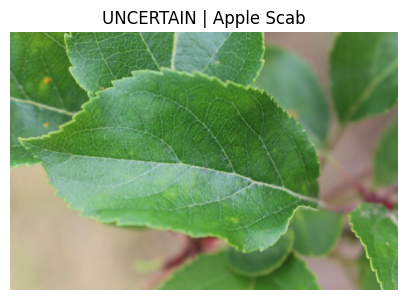

GENUINE APPLE — STANDALONE DEPLOYMENT TEST
Image            : appleleaf9_006944.jpg
True class       : Apple Rust
Predicted class  : Apple Scab
Softmax confidence: 97.19%
kNN score        : 0.9228
Threshold        : 0.9357
Decision         : UNCERTAIN
Diagnosis        : None

TOP-3
1. Apple Scab                     97.19%
2. Healthy Apple Leaf             1.71%
3. Apple Rust                     0.94%

PASS: Standalone predictor successfully processed a genuine Apple image.


In [43]:
# ============================================================
# STEP 36B — TEST STANDALONE PIPELINE ON GENUINE APPLE IMAGE
# ============================================================

from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# PICK ONE GENUINE APPLE IMAGE
# ------------------------------------------------------------

IMAGE_EXTENSIONS = {
    ".jpg", ".jpeg", ".png",
    ".bmp", ".tif", ".tiff", ".webp"
}

apple_test_images = [
    p
    for p in INTERNAL_TEST_DIR.rglob("*")
    if p.is_file()
    and p.suffix.lower() in IMAGE_EXTENSIONS
]

assert len(apple_test_images) == 2510

TEST_APPLE_IMAGE = apple_test_images[0]


# ------------------------------------------------------------
# STANDALONE DEPLOYMENT PREDICTION
# ------------------------------------------------------------

result = predictor.predict(
    TEST_APPLE_IMAGE
)


# ------------------------------------------------------------
# DISPLAY IMAGE
# ------------------------------------------------------------

image = Image.open(
    TEST_APPLE_IMAGE
).convert("RGB")

plt.figure(figsize=(5, 5))
plt.imshow(image)
plt.axis("off")
plt.title(
    f"{result['decision']} | "
    f"{result['predicted_class']}"
)
plt.show()


# ------------------------------------------------------------
# DISPLAY RESULT
# ------------------------------------------------------------

print("=" * 75)
print("GENUINE APPLE — STANDALONE DEPLOYMENT TEST")
print("=" * 75)

print(
    f"Image            : "
    f"{TEST_APPLE_IMAGE.name}"
)

print(
    f"True class       : "
    f"{TEST_APPLE_IMAGE.parent.name}"
)

print(
    f"Predicted class  : "
    f"{result['predicted_class']}"
)

print(
    f"Softmax confidence: "
    f"{result['confidence']*100:.2f}%"
)

print(
    f"kNN score        : "
    f"{result['knn_score']:.4f}"
)

print(
    f"Threshold        : "
    f"{result['accept_threshold']:.4f}"
)

print(
    f"Decision         : "
    f"{result['decision']}"
)

print(
    f"Diagnosis        : "
    f"{result['diagnosis']}"
)


print("\nTOP-3")

for rank, item in enumerate(
    result["top3"],
    start=1
):
    print(
        f"{rank}. "
        f"{item['class']:<30} "
        f"{item['confidence']*100:.2f}%"
    )


# ------------------------------------------------------------
# SAFETY CHECK
# ------------------------------------------------------------

if result["decision"] == "ACCEPT":

    assert result["diagnosis"] is not None

else:

    assert result["diagnosis"] is None


print(
    "\nPASS: Standalone predictor successfully "
    "processed a genuine Apple image."
)

In [44]:
# ============================================================
# STEP 36C — STANDALONE TEST ON WHEAT IMAGE
# ============================================================

from pathlib import Path

# Search Colab workspace for the previously uploaded wheat image
possible_wheat_files = list(
    Path("/content").rglob("Septoria1129.png")
)

if len(possible_wheat_files) == 0:
    print(
        "Wheat image not found in /content.\n"
        "Please upload Septoria1129.png again."
    )

else:

    WHEAT_IMAGE_PATH = possible_wheat_files[0]

    wheat_result = predictor.predict(
        WHEAT_IMAGE_PATH
    )

    print("=" * 75)
    print("WHEAT — STANDALONE DEPLOYMENT TEST")
    print("=" * 75)

    print(
        f"Image             : "
        f"{WHEAT_IMAGE_PATH.name}"
    )

    print(
        f"Internal prediction: "
        f"{wheat_result['predicted_class']}"
    )

    print(
        f"Softmax confidence : "
        f"{wheat_result['confidence']*100:.2f}%"
    )

    print(
        f"kNN score          : "
        f"{wheat_result['knn_score']:.4f}"
    )

    print(
        f"Threshold          : "
        f"{wheat_result['accept_threshold']:.4f}"
    )

    print(
        f"Decision           : "
        f"{wheat_result['decision']}"
    )

    print(
        f"Diagnosis shown    : "
        f"{wheat_result['diagnosis']}"
    )

    print(
        f"\nApp message:\n"
        f"{wheat_result['message']}"
    )

    assert (
        wheat_result["decision"]
        == "UNCERTAIN"
    )

    assert (
        wheat_result["diagnosis"]
        is None
    )

    print(
        "\nPASS: Standalone reliability layer "
        "suppressed the wheat diagnosis."
    )

WHEAT — STANDALONE DEPLOYMENT TEST
Image             : Septoria1129.png
Internal prediction: Apple Mosaic
Softmax confidence : 99.26%
kNN score          : 0.8711
Threshold          : 0.9357
Decision           : UNCERTAIN
Diagnosis shown    : None

App message:
Unable to diagnose this image reliably. Please verify that Apple is selected and capture another clear image of the leaf.

PASS: Standalone reliability layer suppressed the wheat diagnosis.


In [45]:
# ============================================================
# STEP 37 — LOGIN TO HUGGING FACE
# ============================================================

!pip -q install -U huggingface_hub

from huggingface_hub import notebook_login

notebook_login()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 798.3/798.3 kB 1.1 MB/s eta 0:00:00


In [46]:
# ============================================================
# STEP 38 — BUILD CLEAN APPLE V1 HUGGING FACE PACKAGE
# ============================================================

from pathlib import Path
import shutil


# ------------------------------------------------------------
# SOURCE
# ------------------------------------------------------------

DEPLOYMENT_DIR = Path(
    "/content/drive/MyDrive/"
    "final_year_project/Apple/deployment"
)


# ------------------------------------------------------------
# CLEAN PACKAGE LOCATION
# ------------------------------------------------------------

HF_PACKAGE_ROOT = Path(
    "/content/plant-disease-models-package"
)

APPLE_V1_DIR = (
    HF_PACKAGE_ROOT /
    "apple" /
    "v1"
)


# Start clean
if HF_PACKAGE_ROOT.exists():
    shutil.rmtree(HF_PACKAGE_ROOT)

APPLE_V1_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ------------------------------------------------------------
# RUNTIME-REQUIRED FILES ONLY
# ------------------------------------------------------------

RUNTIME_FILES = [

    "model.py",

    "inference.py",

    "config.json",

    "classes.json",

    "apple_model_v1_weights.pth",

    "apple_knn_reference_bank.pt",

    "apple_reliability_config.json"
]


# ------------------------------------------------------------
# COPY
# ------------------------------------------------------------

print("=" * 75)
print("BUILDING APPLE MODEL V1 PACKAGE")
print("=" * 75)

for filename in RUNTIME_FILES:

    source = (
        DEPLOYMENT_DIR /
        filename
    )

    destination = (
        APPLE_V1_DIR /
        filename
    )

    assert source.exists(), (
        f"Missing required file: {source}"
    )

    shutil.copy2(
        source,
        destination
    )

    size_mb = (
        destination.stat().st_size
        / (1024 ** 2)
    )

    print(
        f"✓ {filename:<40} "
        f"{size_mb:>8.2f} MB"
    )


# ------------------------------------------------------------
# CREATE requirements.txt
# ------------------------------------------------------------

requirements = """torch
torchvision
Pillow
"""

requirements_path = (
    APPLE_V1_DIR /
    "requirements.txt"
)

requirements_path.write_text(
    requirements,
    encoding="utf-8"
)


# ------------------------------------------------------------
# VERIFY PACKAGE
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("FINAL PACKAGE STRUCTURE")
print("=" * 75)

total_size = 0

for path in sorted(
    APPLE_V1_DIR.iterdir()
):

    if path.is_file():

        size = path.stat().st_size

        total_size += size

        print(
            f"apple/v1/{path.name}"
        )


print("-" * 75)

print(
    f"Runtime files : "
    f"{len(list(APPLE_V1_DIR.iterdir()))}"
)

print(
    f"Package size  : "
    f"{total_size / (1024 ** 2):.2f} MB"
)


# ------------------------------------------------------------
# MAKE SURE EVALUATION RAW DATA IS NOT INCLUDED
# ------------------------------------------------------------

assert not (
    APPLE_V1_DIR /
    "apple_v1_final_evaluation_raw.pt"
).exists()


print(
    "\n✓ Raw evaluation data excluded"
)

print(
    "✓ Training checkpoints excluded"
)

print(
    "✓ Training dataset excluded"
)

print(
    "\nPASS: Clean Apple Model V1 "
    "package created."
)

print(
    f"\nPackage location:\n"
    f"{APPLE_V1_DIR}"
)


BUILDING APPLE MODEL V1 PACKAGE
✓ model.py                                     0.00 MB
✓ inference.py                                 0.01 MB
✓ config.json                                  0.00 MB
✓ classes.json                                 0.00 MB
✓ apple_model_v1_weights.pth                 118.16 MB
✓ apple_knn_reference_bank.pt                 23.00 MB
✓ apple_reliability_config.json                0.00 MB

FINAL PACKAGE STRUCTURE
apple/v1/apple_knn_reference_bank.pt
apple/v1/apple_model_v1_weights.pth
apple/v1/apple_reliability_config.json
apple/v1/classes.json
apple/v1/config.json
apple/v1/inference.py
apple/v1/model.py
apple/v1/requirements.txt
---------------------------------------------------------------------------
Runtime files : 8
Package size  : 141.18 MB

✓ Raw evaluation data excluded
✓ Training checkpoints excluded
✓ Training dataset excluded

PASS: Clean Apple Model V1 package created.

Package location:
/content/plant-disease-models-package/apple/v1


In [47]:
# ============================================================
# STEP 39 — UPLOAD APPLE MODEL V1 TO HUGGING FACE
# ============================================================

from huggingface_hub import HfApi
from pathlib import Path


# ------------------------------------------------------------
# REPOSITORY
# ------------------------------------------------------------

REPO_ID = "viraj1920/plant-disease-models"

APPLE_V1_DIR = Path(
    "/content/plant-disease-models-package/apple/v1"
)


assert APPLE_V1_DIR.exists()


# ------------------------------------------------------------
# CONNECT TO HUGGING FACE
# ------------------------------------------------------------

api = HfApi()


print("=" * 75)
print("UPLOADING APPLE MODEL V1 TO HUGGING FACE")
print("=" * 75)

print(f"Repository : {REPO_ID}")
print("Destination: apple/v1/")
print(f"Local path : {APPLE_V1_DIR}")

print("\nUploading...")


# ------------------------------------------------------------
# UPLOAD COMPLETE APPLE V1 FOLDER
# ------------------------------------------------------------

commit_info = api.upload_folder(

    folder_path=str(
        APPLE_V1_DIR
    ),

    path_in_repo="apple/v1",

    repo_id=REPO_ID,

    repo_type="model",

    commit_message=(
        "Add Apple Model V1"
    )
)


# ------------------------------------------------------------
# RESULT
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("UPLOAD COMPLETE")
print("=" * 75)

print(
    f"Repository : "
    f"{REPO_ID}"
)

print(
    f"Commit     : "
    f"{commit_info.oid}"
)

print(
    f"Commit URL : "
    f"{commit_info.commit_url}"
)


# ------------------------------------------------------------
# VERIFY REMOTE FILES
# ------------------------------------------------------------

remote_files = api.list_repo_files(
    repo_id=REPO_ID,
    repo_type="model"
)


expected_files = [

    "apple/v1/model.py",

    "apple/v1/inference.py",

    "apple/v1/config.json",

    "apple/v1/classes.json",

    "apple/v1/apple_model_v1_weights.pth",

    "apple/v1/apple_knn_reference_bank.pt",

    "apple/v1/apple_reliability_config.json",

    "apple/v1/requirements.txt"
]


print("\nREMOTE FILE VERIFICATION")
print("-" * 75)

for filename in expected_files:

    exists = filename in remote_files

    print(
        f"{'✓' if exists else '✗'} "
        f"{filename}"
    )

    assert exists, (
        f"Missing remote file: {filename}"
    )


print(
    "\nPASS: Apple Model V1 is stored "
    "successfully on Hugging Face."
)

UPLOADING APPLE MODEL V1 TO HUGGING FACE
Repository : viraj1920/plant-disease-models
Destination: apple/v1/
Local path : /content/plant-disease-models-package/apple/v1

Uploading...

UPLOAD COMPLETE
Repository : viraj1920/plant-disease-models
Commit     : f5987839f98bd254c16e5959a16935b6688eb38b
Commit URL : https://huggingface.co/viraj1920/plant-disease-models/commit/f5987839f98bd254c16e5959a16935b6688eb38b

REMOTE FILE VERIFICATION
---------------------------------------------------------------------------
✓ apple/v1/model.py
✓ apple/v1/inference.py
✓ apple/v1/config.json
✓ apple/v1/classes.json
✓ apple/v1/apple_model_v1_weights.pth
✓ apple/v1/apple_knn_reference_bank.pt
✓ apple/v1/apple_reliability_config.json
✓ apple/v1/requirements.txt

PASS: Apple Model V1 is stored successfully on Hugging Face.


In [48]:
# ============================================================
# STEP 40 — FRESH DOWNLOAD FROM HUGGING FACE
# ============================================================

from huggingface_hub import snapshot_download
from pathlib import Path
import shutil


REPO_ID = "viraj1920/plant-disease-models"

FRESH_ROOT = Path(
    "/content/hf_backend_test"
)


# ------------------------------------------------------------
# REMOVE ANY PREVIOUS TEST DOWNLOAD
# ------------------------------------------------------------

if FRESH_ROOT.exists():
    shutil.rmtree(FRESH_ROOT)

FRESH_ROOT.mkdir(
    parents=True,
    exist_ok=True
)


print("=" * 75)
print("APPLE MODEL V1 — HUGGING FACE DOWNLOAD TEST")
print("=" * 75)

print(f"Repository : {REPO_ID}")
print("Downloading: apple/v1/*")


# ------------------------------------------------------------
# DOWNLOAD ONLY APPLE V1
# ------------------------------------------------------------

downloaded_repo = snapshot_download(

    repo_id=REPO_ID,

    repo_type="model",

    allow_patterns=[
        "apple/v1/*"
    ],

    local_dir=str(
        FRESH_ROOT
    )
)


APPLE_HF_DIR = (
    FRESH_ROOT /
    "apple" /
    "v1"
)


# ------------------------------------------------------------
# VERIFY
# ------------------------------------------------------------

required_files = [

    "model.py",

    "inference.py",

    "config.json",

    "classes.json",

    "apple_model_v1_weights.pth",

    "apple_knn_reference_bank.pt",

    "apple_reliability_config.json",

    "requirements.txt"
]


print("\nDOWNLOADED FILES")
print("-" * 75)

for filename in required_files:

    path = (
        APPLE_HF_DIR /
        filename
    )

    print(
        f"{'✓' if path.exists() else '✗'} "
        f"{filename}"
    )

    assert path.exists(), (
        f"Missing downloaded file: {filename}"
    )


print(
    "\nDownload location:"
)

print(
    APPLE_HF_DIR
)


print(
    "\nPASS: Apple Model V1 downloaded "
    "successfully from Hugging Face."
)

APPLE MODEL V1 — HUGGING FACE DOWNLOAD TEST
Repository : viraj1920/plant-disease-models
Downloading: apple/v1/*


Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 8 files:   0%|          | 0/8 [00:00<?, ?it/s]


DOWNLOADED FILES
---------------------------------------------------------------------------
✓ model.py
✓ inference.py
✓ config.json
✓ classes.json
✓ apple_model_v1_weights.pth
✓ apple_knn_reference_bank.pt
✓ apple_reliability_config.json
✓ requirements.txt

Download location:
/content/hf_backend_test/apple/v1

PASS: Apple Model V1 downloaded successfully from Hugging Face.


In [49]:
# ============================================================
# STEP 41 — LOAD APPLE V1 FROM HUGGING FACE DOWNLOAD
# ============================================================

import sys
import importlib
from pathlib import Path


# ------------------------------------------------------------
# HUGGING FACE DOWNLOADED PACKAGE
# ------------------------------------------------------------

APPLE_HF_DIR = Path(
    "/content/hf_backend_test/apple/v1"
)

assert APPLE_HF_DIR.exists()


# ------------------------------------------------------------
# REMOVE OLD IMPORTS
# ------------------------------------------------------------
# Important:
# Prevent Python from accidentally reusing model.py or
# inference.py imported earlier from Google Drive.

for module_name in [
    "model",
    "inference"
]:
    if module_name in sys.modules:
        del sys.modules[module_name]


# ------------------------------------------------------------
# FORCE PYTHON TO USE HUGGING FACE PACKAGE
# ------------------------------------------------------------

sys.path.insert(
    0,
    str(APPLE_HF_DIR)
)

importlib.invalidate_caches()


# ------------------------------------------------------------
# IMPORT STANDALONE PREDICTOR
# ------------------------------------------------------------

from inference import AppleDiseasePredictor


print("=" * 75)
print("APPLE MODEL V1 — FRESH BACKEND LOAD TEST")
print("=" * 75)

print(
    "Package source :",
    APPLE_HF_DIR
)


# ------------------------------------------------------------
# CREATE PREDICTOR
# ------------------------------------------------------------

predictor = AppleDiseasePredictor(
    model_dir=APPLE_HF_DIR
)


# ------------------------------------------------------------
# VERIFY
# ------------------------------------------------------------

print("\nMODEL LOADED")

print(
    f"Device           : "
    f"{predictor.device}"
)

print(
    f"Classes          : "
    f"{len(predictor.classes)}"
)

print(
    f"K                : "
    f"{predictor.k}"
)

print(
    f"Accept threshold : "
    f"{predictor.accept_threshold:.4f}"
)

print(
    f"Reference images : "
    f"{len(predictor.reference_embeddings):,}"
)

print(
    f"Embedding dim    : "
    f"{predictor.reference_embeddings.shape[1]}"
)


# ------------------------------------------------------------
# VERIFY ACTUAL IMPORT LOCATIONS
# ------------------------------------------------------------

import model
import inference

print("\nIMPORT VERIFICATION")

print(
    "model.py     :",
    model.__file__
)

print(
    "inference.py :",
    inference.__file__
)


assert str(APPLE_HF_DIR) in model.__file__
assert str(APPLE_HF_DIR) in inference.__file__


print(
    "\nPASS: Apple Model V1 loaded entirely "
    "from the Hugging Face package."
)

APPLE MODEL V1 — FRESH BACKEND LOAD TEST
Package source : /content/hf_backend_test/apple/v1


/content/hf_backend_test/apple/v1/model.py:72: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(



MODEL LOADED
Device           : cuda


AttributeError: 'AppleDiseasePredictor' object has no attribute 'classes'

In [50]:
# ============================================================
# STEP 41A — INSPECT ACTUAL PREDICTOR ATTRIBUTES
# ============================================================

print("=" * 75)
print("APPLE MODEL V1 — PREDICTOR INSPECTION")
print("=" * 75)

print("\nAvailable predictor attributes:\n")

for name in sorted(vars(predictor).keys()):
    value = getattr(predictor, name)

    if hasattr(value, "shape"):
        print(f"{name:<30} shape={tuple(value.shape)}")
    else:
        print(f"{name:<30} {type(value).__name__}")


# ------------------------------------------------------------
# VERIFY IMPORT SOURCE
# ------------------------------------------------------------

import model
import inference

print("\n" + "=" * 75)
print("IMPORT SOURCE")
print("=" * 75)

print("model.py     :", model.__file__)
print("inference.py :", inference.__file__)

assert str(APPLE_HF_DIR) in model.__file__
assert str(APPLE_HF_DIR) in inference.__file__

print(
    "\n✓ Both modules are being loaded from "
    "the Hugging Face-downloaded package."
)

APPLE MODEL V1 — PREDICTOR INSPECTION

Available predictor attributes:

accept_threshold               float
class_names                    list
config                         dict
device                         device
k                              int
model                          ResNet50SelfAttention
model_dir                      PosixPath
reference_embeddings           shape=(11731, 512)
reliability_config             dict
transform                      Compose

IMPORT SOURCE
model.py     : /content/hf_backend_test/apple/v1/model.py
inference.py : /content/hf_backend_test/apple/v1/inference.py

✓ Both modules are being loaded from the Hugging Face-downloaded package.


In [51]:
# ============================================================
# STEP 41B — FINAL HUGGING FACE INFERENCE TEST
# ============================================================

from pathlib import Path
import json


print("=" * 75)
print("APPLE MODEL V1 — FINAL DEPLOYMENT INFERENCE TEST")
print("=" * 75)


# ------------------------------------------------------------
# FIND ONE GENUINE APPLE TEST IMAGE
# ------------------------------------------------------------

DATASET_ROOT = Path(
    "/content/apple_dataset/Apple_final_dataset"
)

INTERNAL_TEST = (
    DATASET_ROOT /
    "internal_test"
)


image_extensions = {
    ".jpg",
    ".jpeg",
    ".png",
    ".JPG",
    ".JPEG",
    ".PNG"
}


test_images = [
    p
    for p in INTERNAL_TEST.rglob("*")
    if p.is_file()
    and p.suffix in image_extensions
]


assert len(test_images) > 0, (
    "No internal-test image found."
)


TEST_IMAGE = test_images[0]

true_class = TEST_IMAGE.parent.name


print(f"\nTest image : {TEST_IMAGE.name}")
print(f"True class : {true_class}")


# ------------------------------------------------------------
# RUN STANDALONE HUGGING FACE PREDICTOR
# ------------------------------------------------------------

result = predictor.predict(
    TEST_IMAGE
)


# ------------------------------------------------------------
# DISPLAY RESULT
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("BACKEND-STYLE RESULT")
print("=" * 75)

print(
    json.dumps(
        result,
        indent=2
    )
)


# ------------------------------------------------------------
# BASIC CONTRACT CHECK
# ------------------------------------------------------------

assert result["crop"] == "Apple"

assert result["decision"] in {
    "ACCEPT",
    "UNCERTAIN"
}

assert (
    result["predicted_class"]
    in predictor.class_names
)

assert 0.0 <= result["confidence"] <= 1.0

assert 0.0 <= result["knn_score"] <= 1.0


# ACCEPT must expose diagnosis.
# UNCERTAIN must suppress diagnosis.

if result["decision"] == "ACCEPT":

    assert (
        result["diagnosis"]
        == result["predicted_class"]
    )

else:

    assert result["diagnosis"] is None


print("\n" + "=" * 75)
print("DEPLOYMENT CONTRACT CHECK")
print("=" * 75)

print("✓ Crop field valid")
print("✓ Decision field valid")
print("✓ Predicted class valid")
print("✓ Confidence valid")
print("✓ kNN reliability score valid")
print("✓ Diagnosis suppression policy valid")

print(
    "\nPASS: Apple Model V1 performed "
    "standalone inference successfully."
)

APPLE MODEL V1 — FINAL DEPLOYMENT INFERENCE TEST

Test image : appleleaf9_006944.jpg
True class : Apple Rust

BACKEND-STYLE RESULT
{
  "crop": "Apple",
  "decision": "UNCERTAIN",
  "knn_score": 0.9228240251541138,
  "accept_threshold": 0.9357,
  "predicted_index": 6,
  "predicted_class": "Apple Scab",
  "confidence": 0.971925675868988,
  "top3": [
    {
      "class": "Apple Scab",
      "confidence": 0.971925675868988
    },
    {
      "class": "Healthy Apple Leaf",
      "confidence": 0.017091695219278336
    },
    {
      "class": "Apple Rust",
      "confidence": 0.009444904513657093
    }
  ],
  "diagnosis": null,
  "message": "Unable to diagnose this image reliably. Please verify that Apple is selected and capture another clear image of the leaf."
}

DEPLOYMENT CONTRACT CHECK
✓ Crop field valid
✓ Decision field valid
✓ Predicted class valid
✓ Confidence valid
✓ kNN reliability score valid
✓ Diagnosis suppression policy valid

PASS: Apple Model V1 performed standalone inference 